# Taller 3 MCMC Metropolis
- Ignacio Allendes - 202004531-3
- Felipe Asbún - 202010509-K

El objetivo de este notebook es que se ejerciten con la aplicación de SVMs y árboles de decisión a problemas de clasificación.


<table align='left'>
<tr>
<td><img src='https://blog.schoolforai.com/content/images/size/w1000/2021/12/Salary-pred.png' width='750'/> </td>
</tr>
</table>

Declaramos que el trabajo realizado es original. Destacamos los códigos realizados por Felipe, principalmente en Más allá de lo evidente y Kernels, y las contribuciones de Ignacio en SVM y el entendimiento de Árboles.

Agradecemos los códigos guía del profesor.

Link: https://youtu.be/YoTD796lKl0

# Base Imports

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt

# Set ggplot styles and update Matplotlib with them.
ggplot_styles = {
    'axes.grid': False
}

plt.rcParams.update(ggplot_styles)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({'font.size': 8})
plt.rc('xtick',labelsize=8)
plt.rc('ytick',labelsize=8)
plt.rc('axes', labelsize=8)
plt.rc('legend',fontsize=10)

# Datos

Los datos a utilizar han sido distribuidos con los enunciados de este taller. Para  facilitar el desarrollo del taller, el conjunto de entrenamiento se encuentra disponible en dos versiones: uno pequeño (salary_train.csv) y uno grande (salary_train_large.csv). El conjunto de pruebas es el mismo para todos y se debe obtener del archivo salary_test.csv.

La variable a predecir corresponde a la columna "salario".

In [ ]:
!wget http://www.inf.utfsm.cl/~jnancu/salary_train.csv
!wget http://www.inf.utfsm.cl/~jnancu/salary_train_large.csv
!wget http://www.inf.utfsm.cl/~jnancu/salary_test.csv

URL transformed to HTTPS due to an HSTS policy
--2023-11-16 00:14:43--  https://www.inf.utfsm.cl/~jnancu/salary_train.csv
Resolving www.inf.utfsm.cl (www.inf.utfsm.cl)... 200.1.19.11, 2800:270:c::11
Connecting to www.inf.utfsm.cl (www.inf.utfsm.cl)|200.1.19.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 608982 (595K) [application/octet-stream]
Saving to: ‘salary_train.csv.1’

salary_train.csv.1  100%[===================>] 594.71K  1.07MB/s    in 0.5s    

2023-11-16 00:14:44 (1.07 MB/s) - ‘salary_train.csv.1’ saved [608982/608982]

URL transformed to HTTPS due to an HSTS policy
--2023-11-16 00:14:44--  https://www.inf.utfsm.cl/~jnancu/salary_train_large.csv
Resolving www.inf.utfsm.cl (www.inf.utfsm.cl)... 200.1.19.11, 2800:270:c::11
Connecting to www.inf.utfsm.cl (www.inf.utfsm.cl)|200.1.19.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2440577 (2.3M) [application/octet-stream]
Saving to: ‘salary_train_large.csv.1’

salary_tra

In [ ]:
path = ""

In [ ]:
!pwd

/content


In [ ]:
data_train_small = pd.read_csv(path+'salary_train.csv')
data_train_large = pd.read_csv(path+'salary_train_large.csv')
data_test = pd.read_csv(path+'salary_test.csv')
print(len(data_train_small))
print(len(data_train_large))
print(len(data_test))

5209
20839
6513


In [ ]:
display(data_train_small.head(5))
display(data_test.head(5))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,75,?,173064,Bachelors,13,Married-civ-spouse,?,Husband,White,Male,0,0,6,United-States,<=50K
1,17,Private,63734,10th,6,Never-married,Handlers-cleaners,Own-child,White,Male,0,0,20,United-States,<=50K
2,41,Private,195124,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,35,Dominican-Republic,<=50K
3,37,Private,111499,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,24,Private,162282,HS-grad,9,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,salary
0,79,Private,120707,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,20051,0,35,El-Salvador,>50K
1,66,Private,141085,HS-grad,9,Widowed,Priv-house-serv,Not-in-family,White,Female,0,0,8,United-States,<=50K
2,61,?,167284,7th-8th,4,Widowed,?,Not-in-family,Black,Female,0,0,40,United-States,<=50K
3,66,?,196736,1st-4th,2,Never-married,?,Not-in-family,Black,Male,0,0,30,United-States,<=50K
4,29,Private,187188,Masters,14,Never-married,Exec-managerial,Not-in-family,Asian-Pac-Islander,Male,0,0,60,United-States,<=50K


# P1. Exploratorio I

In [ ]:
data_train = data_train_large

Conduzca un breve análisis exploratorio de datos, determinando:

*   De cuántos datos y de cuántos atributos se dispone?

R: Se disponen de 12 atributos, con 20839 datos para el dataframe grande y 6513 para el dataframe pequeño.

*   Qué valores puede tomar la variable a predecir?

R: La variable a predecir, 'salary', toma valores en $\{0,1\}$

*   Se trata de un problema de clasificación desbalanceado?

R: Efectivamente es un problema desbalanceado, con una distribución 3:1 entre salary <50k y >=50k

*   Cuáles atributos son continuos y cuáles son categóricos?

R: Hay 8 atributos categóricos y 6 continuos:
    
    categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']
    continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

*   Puede atribuir una semántica (significado) a cada variable?

R:
1. 'workclass': Tipo de trabajo
2. 'education': Nivel académico
3. 'marital-status': Estado civil
4. 'occupation': Sector económico donde trabaja
5. 'relationship': Puesto familiar
6. 'race': Raza de la persona
7. 'sex': Sexo
8. 'native-country': País natal
9. 'age': Edad
10. 'capital-gain': Capital ganado en el año
11. 'capital-loss': Capital perdido en el año
12. 'hours-per-week': Horas de chamba semanales

*   Existen datos faltantes? Se concentran en algún atributo?

R: No hay datos nulos, pero hay atributos que contienen datos desconocidos clasificados como '?'

*   Cómo se distribuyen los atributos continuos? Existen outliers?

R: Efectivamente, los datos continuos poseen outliers. La distribución está graficada más abajo.

*   Cómo se distribuyen los atributos categóricos?

R: Distribución puesta más abajo.


In [ ]:
data_train_small['hours-per-week'].unique()

array([ 6, 20, 35, 40, 65, 72, 50, 45, 60, 24, 36, 55, 25, 84, 48, 38, 12,
       52, 30, 42, 32, 15, 80, 37, 10,  8, 70, 16, 56, 51, 46, 99, 75, 44,
       59, 14, 34, 43, 53, 27,  5,  4, 22, 33, 18, 21, 41,  3, 66, 17, 28,
       39, 26, 54,  7, 47, 13, 64,  9, 49, 23,  2, 90, 85, 29, 57, 68, 86,
       58,  1, 73, 62, 19, 78, 31, 11, 98, 96, 77, 82])

In [ ]:
print(data_train.shape)
print(data_test.shape)

(20839, 15)
(6513, 15)


In [ ]:
#atributos
print(data_train.columns)
class_column = 'salary'

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'salary'],
      dtype='object')


In [ ]:
data_train.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
salary            object
dtype: object

In [ ]:
#print missing
print(data_train.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
salary            0
dtype: int64


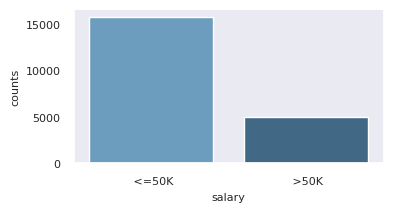

In [ ]:
gr = data_train.groupby([class_column]).size().reset_index(name='counts')

fig, ax = plt.subplots(figsize=(4,2), nrows=1, ncols=1)
sns.barplot(data=gr, x=class_column, y='counts', palette="Blues_d",ax=ax)
plt.show()

In [ ]:
categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']
continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']


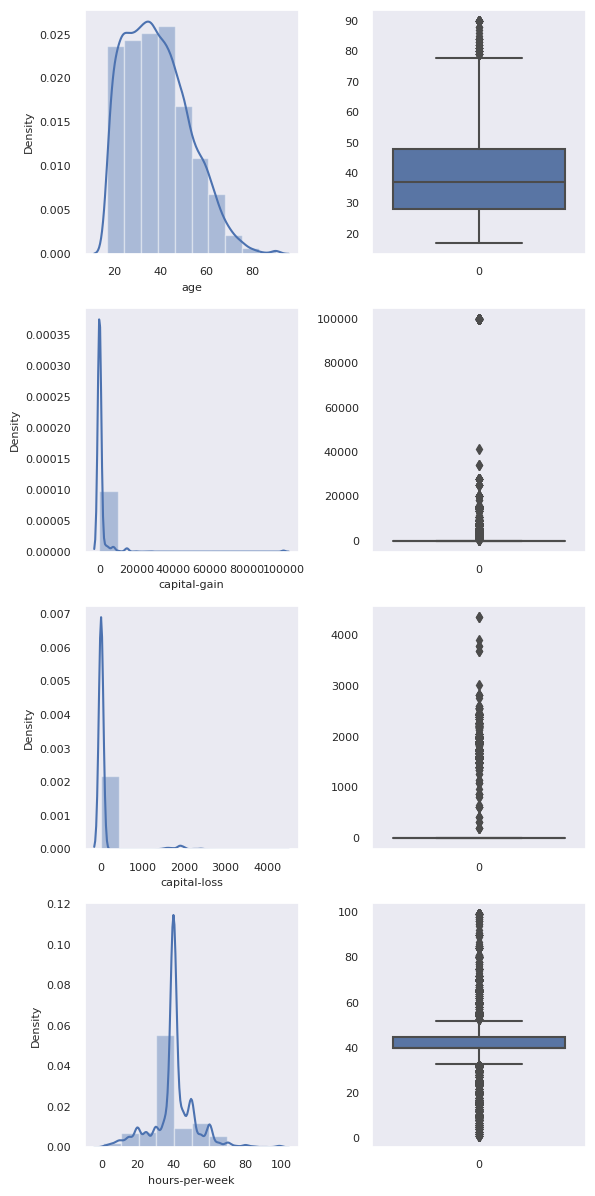

In [ ]:
fig, ax = plt.subplots(figsize=(6,12), nrows=len(continuous_features), ncols=2)

for i, col in enumerate(continuous_features):
    sns.distplot(data_train[col], hist=True, rug=False, kde=True, bins=10, ax=ax[i,0])
    sns.boxplot(data_train[col], ax=ax[i,1])
fig.tight_layout()
plt.show()

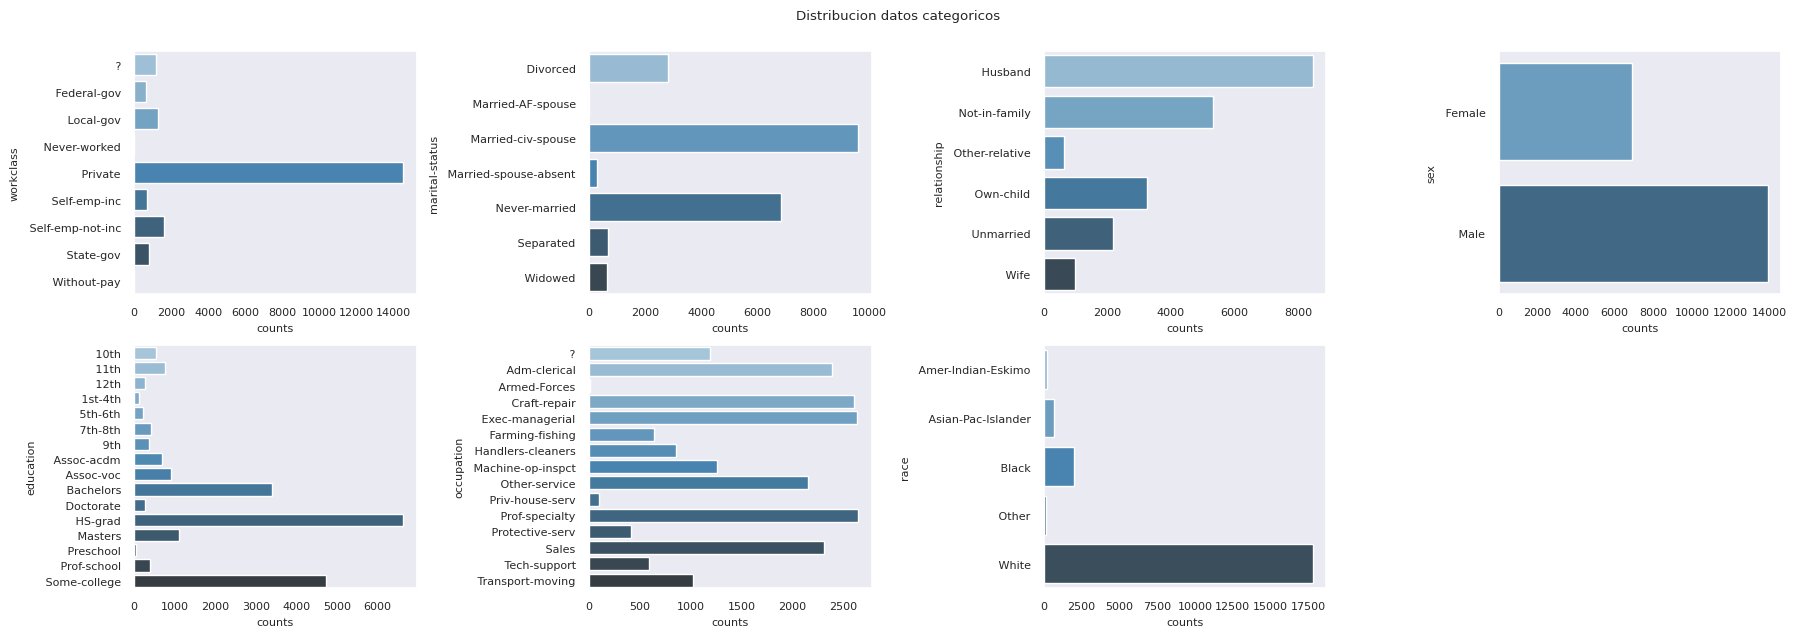

In [ ]:
categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']

fig, axes = plt.subplots(figsize=(18,6), nrows=2, ncols=4)
for i, column in enumerate(categorical_features):
    if i<len(categorical_features)-1:
        df_gb = data_train.groupby([column]).size().reset_index(name='counts')
        sns.barplot(data=df_gb, y=column, x='counts', palette="Blues_d",ax=axes[i%2, i//2])
    axes[1,3].set_axis_off()
fig.tight_layout()
fig.suptitle('Distribucion datos categoricos', y=1.05)
plt.show()

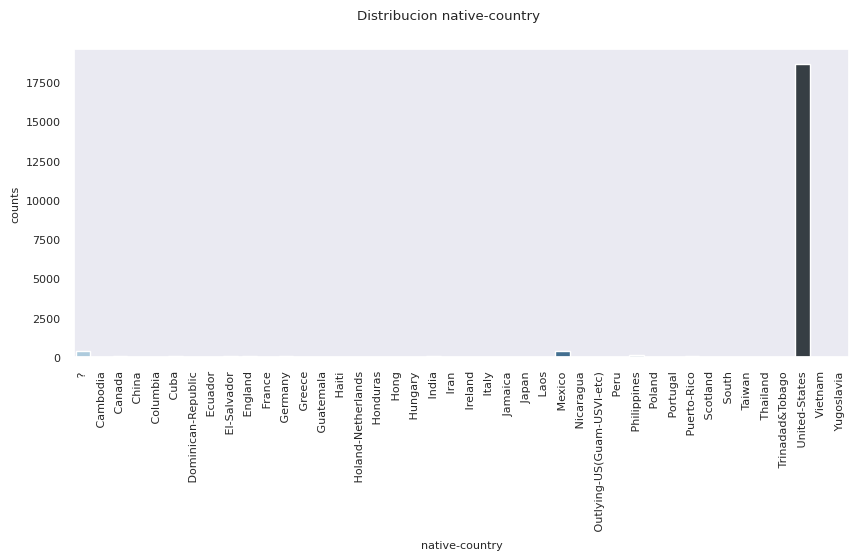

In [ ]:
column = 'native-country'
fig, axes = plt.subplots(figsize=(10,4), nrows=1, ncols=1)
df_gb = data_train.groupby([column]).size().reset_index(name='counts')
sns.barplot(data=df_gb, x=column, y='counts', palette="Blues_d", ax=axes)
fig.suptitle('Distribucion native-country')
_=plt.xticks(rotation=90)

# P2. Exploratorio II y Codificación

In [ ]:
data_train = data_train_large

Expanda su análisis anterior para determinar a nivel explorartorio qué variables podrían ser más útiles para predecir la variable de interés.

*   Utilice alguna técnica visual que le permita examinar la relevancia de cada predictor.
*   Utilice alguna técnica de filtrado individual que le permita examinar la relevancia de cada predictor.

R: Podemos utilizar mutual_info_classif que mide la independencia entre variables utilizando técnicas KNN. En este caso, se utilizará para medir la dependencia entre cada variable y la clase.


*   Razone sobre las limitaciones de las técnicas empleadas.

R: Como se mide de forma individual cada predictor, no se visualizan los efectos conjuntos entre las variables, por lo que un conjunto de variables podría ser relevante, pero no individualmente.


In [ ]:
from sklearn.feature_selection import mutual_info_classif as mi
from sklearn.preprocessing import LabelEncoder


scores = []
y = LabelEncoder().fit_transform(data_train[class_column]).reshape(-1,1)
for pred in categorical_features:
    x = LabelEncoder().fit_transform(data_train[pred]).reshape(-1,1)
    score = mi(x, y, discrete_features=True)[0]
    scores.append(score)
for pred in continuous_features:
    x = data_train[pred].to_numpy().reshape(-1,1)
    score = mi(x, y, discrete_features=False)[0]
    scores.append(score)

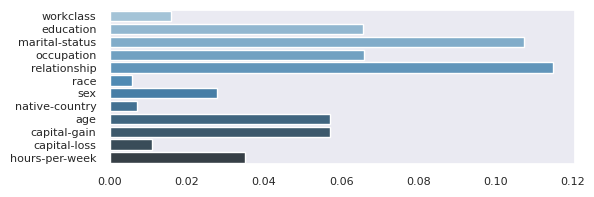

In [ ]:
fig, axes = plt.subplots(figsize=(6,2), nrows=1, ncols=1)
plot_data = {'x': categorical_features + continuous_features, 'y': scores}
p = sns.barplot(data=plot_data,x='y', y='x', palette="Blues_d",ax=axes)
plt.show()

# P3. Preparación de los Datos

In [ ]:
data_train = data_train_small

Genere una nueva versión del dataset original pre-procesando adecuadamente los atributos y preparándo los datos para entrenar un modelo de aprendizaje automático.

*   Explique brevemente en qué consiste la codificación one-hot de las variables categóricas y argumente sobre la necesidad de aplicarlo antes de entrenar una SVM o un árbol de clasificación.

R: OneHotEncoder codifica las clases categóricas en un vector binario, donde cada coordenada se corresponde con un valor único de la clase. Luego, por cada dato, OneHotEncoder asigna 1 en la coordenada del valor que tiene el dato, y 0 en el resto de coordenadas.

*   Proponga un método para escalar los atributos continuos y razone sobre las ventajas que podría tener sobre métodos alternativos. Refiérase en particular a la diferencia entre normalizar y estandarizar.

R: Podemos escalar los atributos continuos ya sea normalizando (StandarScaler) o estandarizando (MinMaxScaler).

Normalizar consiste en escalar de acuerdo con la media $\mu$ y varianza $\sigma^2$ de los datos, de modo que cada dato $x_i$ se transforma de la siguiente forma:

$$
\hat{x_i} = \frac{x_i - \mu}{\sigma}
$$

En cambio, estandarizar toma el máximo y el mínimo de los datos, de forma que todos se escalen al intervalor $[0,1]$. La transformación está data por

$$
\hat{x_i} = \frac{x_i - x_{min}}{x_{max} - x_{min}}
$$

En este caso, escogeremos MinMaxScaler.

*   Aplique su método explicando claramente si las estadísticas requeridas para aplicarlo se deben obtener del conjunto de entrenamiento o del conjunto de pruebas.

R: Las estadísticas se deben obtener del conjunto de entrenamiento para evitar fugas de información al momento de entrenar los datos.

*   Codifique numéricamente la variable a predecir recordando la codificación efectuada.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

X_train_encoded = data_train[continuous_features]
X_test_encoded = data_test[continuous_features]

continuous_scaler = MinMaxScaler()
continuous_scaler.fit(X_train_encoded)

X_train_encoded = pd.DataFrame(continuous_scaler.transform(X_train_encoded),columns=continuous_features)
X_test_encoded = pd.DataFrame(continuous_scaler.transform(X_test_encoded),columns=continuous_features)

categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']

categorical_encoder = OneHotEncoder(sparse=False)
cat_X_train_encoded = categorical_encoder.fit_transform(data_train[categorical_features])
cat_X_train_encoded = pd.DataFrame(cat_X_train_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.concat([X_train_encoded,cat_X_train_encoded],axis=1)
cat_X_test_encoded = categorical_encoder.transform(data_test[categorical_features])
cat_X_test_encoded = pd.DataFrame(cat_X_test_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_test_encoded = pd.concat([X_test_encoded,cat_X_test_encoded],axis=1)


In [ ]:
X_train_encoded

,age,capital-gain,capital-loss,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.794521,0.0,0.0,0.051020,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.000000,0.0,0.0,0.193878,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.328767,0.0,0.0,0.346939,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.273973,0.0,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.095890,0.0,0.0,0.397959,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5204,0.068493,0.0,0.0,0.142857,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5205,0.315068,0.0,0.0,0.397959,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5206,0.000000,0.0,0.0,0.153061,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5207,0.465753,0.0,0.0,0.438776,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(5209, 105)
(6513, 105)


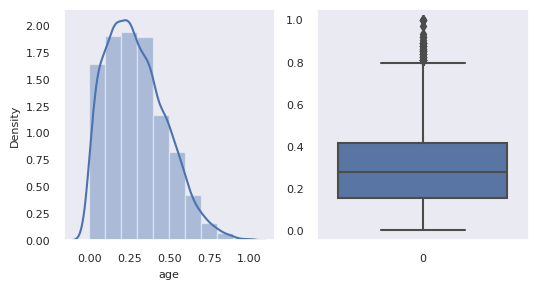

In [ ]:
fig, ax = plt.subplots(figsize=(6,3), nrows=1, ncols=2)
sns.distplot(X_train_encoded['age'], hist=True, rug=False, kde=True, bins=10, ax=ax[0])
sns.boxplot(X_train_encoded['age'], ax=ax[1])
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_class = LabelEncoder()

class_column = 'salary'
y_train = le_class.fit_transform(data_train[class_column])
y_test = le_class.transform(data_test[class_column])

# P4. SVM Lineal I

Estudie el desempeño de una SVM Lineal en el problema.

*   Entrene una SVM lineal eligiendo el valor de C en una C-SVM de modo de aproximar una "hard-margin SVM". Mida la exactitud (accuracy) sobre el conjunto de entrenamiento. ¿Porqué no es 100%?

R: Note que aumentar el valor de C disminuye la regularización del modelo, por lo que escogeremos un valor grande de C.

Dado que es una SVM lineal de márgenes duros, trata de ajustar el hiperplano con el mayor margen posible, sin embargo, puede no ser capaz pues los datos pueden ser no linealmente separables.

*  Proponga un método para encontrar los "support vectors" del modelo y determine qué porcentaje representan del conjunto de entrenamiento total.

R: Note que la función de decisión en LinearSVC mide la distancia, relativa en magnitud, de un vector respecto al hiperplano. En particular, para los support vectors con kernel lineal, la función de decisión toma valores menores o iguales que 1 en valor absoluto para los support vectors, por tanto, podemos identificarlos de esta forma.

*   Proponga un método que permita estimar la exactitud del modelo anterior sobre datos no vistos en la fase de entrenamiento. Evalúe la exactitud sobre el conjunto de pruebas, compare con su estimación, y comente sobre la capacidad de generalización del modelo.

R: Podemos estimar la exactitud del modelo sobre datos no vistos a través de cross-validation.

*   Utilice el método anterior para evaluar diferentes valores de C y elegir un modelo apropiado. Explique porqué la SVM lineal no obtiene error 0 al aumentar el valor de C.

R: Igual que en la primera pregunta, aumentar el valor de C disminuye la regularización, pero la SVM es lineal, es posible que los datos no sean linealmente separables, por lo que no puede alcanzar error 0.

*   Sólo con fines educativos, utilice el conjunto de pruebas para evaluar los diferentes modelos entrenados en el punto anteror, determinnado si el modelo seleccionado es efectivamente óptimo o casi óptimo en este conjunto.  

*   Estudie cómo cambia el número de support vectors a medida que disminuye el valor de C.

*   Estudie el desempeño detallado del modelo seleccionado explicando la diferencia entre métricas como exactitud, precisión, y recall. Determine si el modelo tiene mayor dificultad con alguna de las clases.

In [ ]:
from sklearn.svm import LinearSVC
svm = LinearSVC(C=10**(12), loss='hinge', random_state=42)
svm.fit(X_train_encoded,y_train)

LinearSVC(C=1000000000000, loss='hinge', random_state=42)

In [ ]:
decision_function = svm.decision_function(X_train_encoded)
support_vector_indices = np.where(np.abs(decision_function) <= 1)[0]
print("#SV: ", len(support_vector_indices))

#SV:  2107


In [ ]:
from sklearn.model_selection import cross_val_score

y_pred_train = svm.predict(X_train_encoded)
y_pred_test = svm.predict(X_test_encoded)
print("Accuracy training set    : ", np.sum(y_pred_train==y_train)/len(y_train))
print("Accuracy test set        : ", np.sum(y_pred_test==y_test)/len(y_test))

cv_score = cross_val_score(svm, X_train_encoded, y_train, scoring='accuracy', cv=5)

print('5-Cross Validation Score:')
print('     Mean:', cv_score.mean())
print('     Std :', cv_score.std())

Accuracy training set    :  0.8327894029564216
Accuracy test set        :  0.8283433133732535
5-Cross Validation Score:
     Mean: 0.7828853844579534
     Std : 0.05315238511221661


In [ ]:
from sklearn.metrics import f1_score
from sklearn.svm import LinearSVC

C_values = np.logspace(-3, 3, num=7, endpoint=True, base=10.0)
print(C_values)

test_accuracy = []
train_accuracy = []
cross_val_accuracy = []
cross_val_std = []
n_supp_vect = []

models = []

for C_val in C_values:
    svm = LinearSVC(C=C_val,loss='hinge', random_state=42)
    cv_output = cross_val_score(svm, X_train_encoded, y_train, cv=10, scoring='f1')
    cross_val_accuracy.append(cv_output.mean())
    cross_val_std.append(cv_output.std())

    svm = LinearSVC(C=C_val,loss='hinge', random_state=42)
    svm.fit(X_train_encoded,y_train)

    train_accuracy.append(svm.score(X_train_encoded,y_train))
    test_accuracy.append(svm.score(X_test_encoded,y_test))
    models.append(svm)
    n_supp_vect.append(len(np.where(np.abs(svm.decision_function(X_train_encoded))<=1)[0]))
    print("Done C=",C_val)

C_lin_max = C_values[np.argmax(cross_val_accuracy)]

[1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
Done C= 0.001
Done C= 0.01
Done C= 0.1
Done C= 1.0
Done C= 10.0
Done C= 100.0
Done C= 1000.0


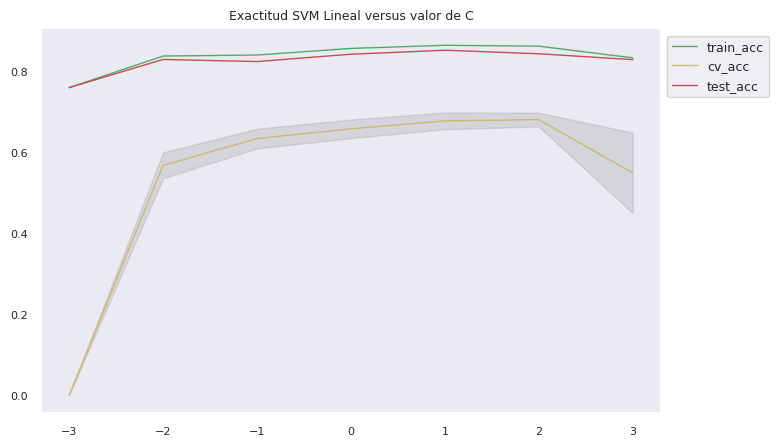

In [ ]:
cross_val_accuracy = np.array(cross_val_accuracy)
cross_val_std = np.array(cross_val_std)

lw=1
fs=9

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.log10(C_values),train_accuracy,color='g',lw=lw,label='train_acc')
ax.plot(np.log10(C_values),cross_val_accuracy,color='y',lw=lw,label='cv_acc')
plt.fill_between(np.log10(C_values), cross_val_accuracy-cross_val_std, cross_val_accuracy+cross_val_std,color='gray', alpha=0.2)
ax.plot(np.log10(C_values),test_accuracy,color='r',lw=lw,label='test_acc')
plt.title("Exactitud SVM Lineal versus valor de C",size=fs)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.9),fontsize=fs)
plt.show()

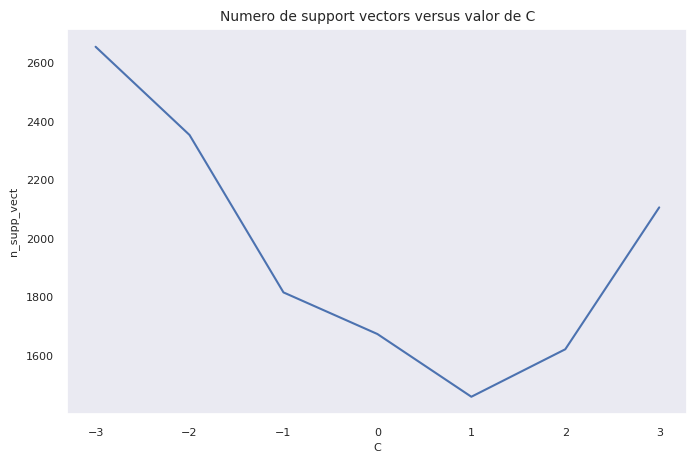

In [ ]:
n_supp_vect = np.array(n_supp_vect)

lw=1
fs=10

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.log10(C_values), n_supp_vect, color='b')
plt.title("Numero de support vectors versus valor de C",size=fs)
plt.ylabel('n_supp_vect')
plt.xlabel('C')
plt.show()

Train Set Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     15820
           1       0.74      0.58      0.65      5019

    accuracy                           0.85     20839
   macro avg       0.81      0.76      0.78     20839
weighted avg       0.84      0.85      0.84     20839

Test Set Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4945
           1       0.73      0.58      0.64      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513



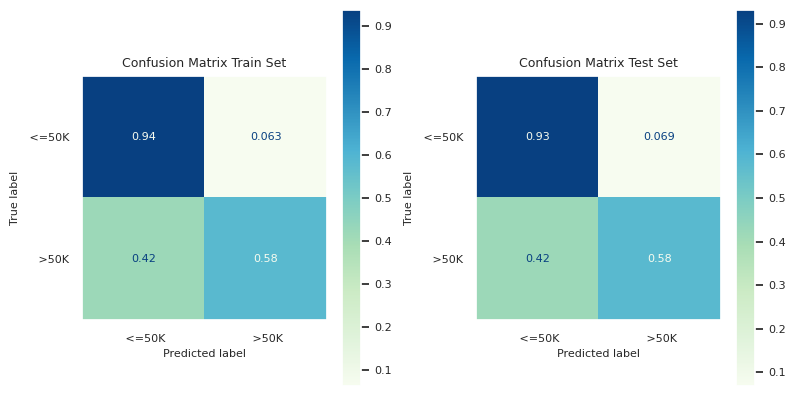

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

svm_linear = LinearSVC(C=C_lin_max, loss='hinge', random_state=42)
svm_linear.fit(X_train_encoded,y_train)

y_pred_train = svm_linear.predict(X_train_encoded)
y_pred_test = svm_linear.predict(X_test_encoded)
print('Train Set Report:')
print(classification_report(y_train, y_pred_train))
print('Test Set Report:')
print(classification_report(y_test, y_pred_test))

fig, ax = plt.subplots(figsize=(8,4), ncols=2, nrows=1)

cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le_class.classes_)
disp_train = disp_train.plot(ax=ax[0],cmap=plt.cm.GnBu)
ax[0].set_title('Confusion Matrix Train Set', size=9)

cm_test = confusion_matrix(y_test, y_pred_test, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le_class.classes_)
disp_test = disp_test.plot(ax=ax[1],cmap=plt.cm.GnBu)
ax[1].set_title('Confusion Matrix Test Set', size=9)

fig.tight_layout()
plt.show()

# P5. SVM No-Lineal

Estudie el desempeño de una SVM con kernel RBF en el problema.

*   Entrene una SVM con kernel RBF. Utilice el valor por defecto del parámetro gamma explicando cómo se determina. Para comenzar, utilice un valor de C que aproxime una "hard-margin SVM". Mida la exactitud (accuracy) sobre el conjunto de entrenamiento y el número de support vectors obtenidos.

R: El valor por defecto de gamma corresponde a 1/(n_features*X_var), con n_features la cantidad de atributos del modelo y X_var la varianza de los datos.

*   Proponga un método que permita estimar la exactitud del modelo anterior sobre datos no vistos en la fase de entrenamiento. Evalúe la exactitud sobre el conjunto de pruebas, compare con su estimación, y comente sobre la capacidad de generalización del modelo.

R: Nuevamente, podemos estimar la exactitud a través de Cross-Validation.

*   Utilice el método anterior para evaluar diferentes valores de C y elegir un valor apropiado. Expliqué porqué a diferencia de la SVM lineal, en este caso sí se llega a error de entrenamiento 0 al aumentar el valor de C.

R: Disminuye el error puesto que la SVM con kernel RBF es capaz de aproximar curvas no lineales que se ajusten perfectamente a losdatos, de modo que separen todos los datos de las clases.

*   Sólo con fines educativos, utilice el conjunto de pruebas para evaluar los diferentes modelos entrenados en el punto anteror, determinando si el modelo seleccionado es efectivamente óptimo o casi óptimo en este conjunto.  

*   Estudie cómo cambia el número de support vectors a medida que disminuye el valor de C.

*   Proponga y ejecute un método para elegir automáticamente el valor de C.

*   Estudie el desempeño detallado del modelo seleccionado explicando la diferencia entre métricas como exactitud, precisión, y recall. Determine si el modelo tiene mayor dificultad con alguna de las clases.

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10**(3), cache_size=1000, random_state=42)
svm.fit(X_train_encoded,y_train)

SVC(C=1000, cache_size=1000, random_state=42)

In [ ]:
print("#SV: ",np.sum(svm.n_support_))

#SV:  1726


In [ ]:
y_pred_train = svm.predict(X_train_encoded)
y_pred_test = svm.predict(X_test_encoded)
print("Accuracy Train Set: ", np.sum(y_pred_train==y_train)/len(y_train))
print("Accuracy Test Set: ", np.sum(y_pred_test==y_test)/len(y_test))

cv_score = cross_val_score(svm, X_train_encoded, y_train, scoring='accuracy', cv=5)

print('5-Cross Validation Score:')
print('     Mean:', cv_score.mean())
print('     Std :', cv_score.std())

Accuracy Train Set:  0.9341524284891534
Accuracy Test Set:  0.8248119146322739
5-Cross Validation Score:
     Mean: 0.8216580838223987
     Std : 0.009115320475193183


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

C_values = np.logspace(-2, 3, num=6, endpoint=True, base=10.0)
print(C_values)

test_accuracy_rbf = []
cross_val_accuracy_rbf = []
cross_val_std_rbf = []
train_accuracy_rbf = []
rbf_models = []

for C_val in C_values:
    svm = SVC(kernel='rbf', C=C_val)
    cv_output = cross_val_score(svm, X_train_encoded, y_train, cv=5)
    cross_val_accuracy_rbf.append(cv_output.mean())
    cross_val_std_rbf.append(cv_output.std())

    svm = SVC(kernel='rbf', C=C_val)
    svm.fit(X_train_encoded,y_train)
    train_accuracy_rbf.append(svm.score(X_train_encoded,y_train))
    test_accuracy_rbf.append(svm.score(X_test_encoded,y_test))
    rbf_models.append(svm)
    print("done C=", C_val)


[1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
done C= 0.01
done C= 0.1
done C= 1.0
done C= 10.0
done C= 100.0
done C= 1000.0


In [ ]:
cross_val_accuracy_rbf = np.array(cross_val_accuracy_rbf)
cross_val_std_rbf = np.array(cross_val_std_rbf)
train_accuracy_rbf = np.array(train_accuracy_rbf)

C_rbf_max = C_values[np.argmax(cross_val_accuracy_rbf[(np.abs(train_accuracy_rbf - cross_val_accuracy_rbf) <= 2*cross_val_std_rbf).tolist()])]
print(C_rbf_max)

1.0


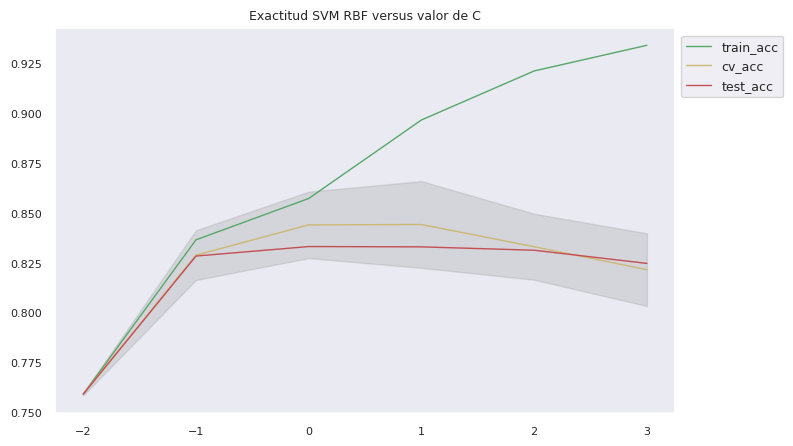

In [ ]:
cross_val_accuracy_rbf = np.array(cross_val_accuracy_rbf)
cross_val_std_rbf = np.array(cross_val_std_rbf)

lw=1
fs=9

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(np.log10(C_values),train_accuracy_rbf,color='g',lw=lw,label='train_acc')
ax.plot(np.log10(C_values),cross_val_accuracy_rbf,color='y',lw=lw,label='cv_acc')
plt.fill_between(np.log10(C_values), cross_val_accuracy_rbf-2*cross_val_std_rbf, cross_val_accuracy_rbf+2*cross_val_std_rbf,color='gray', alpha=0.2)
ax.plot(np.log10(C_values),test_accuracy_rbf,color='r',lw=lw,label='test_acc')
plt.title("Exactitud SVM RBF versus valor de C",size=fs)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.9),fontsize=fs)
plt.show()

Train Set Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      3955
           1       0.77      0.59      0.66      1254

    accuracy                           0.86      5209
   macro avg       0.82      0.77      0.79      5209
weighted avg       0.85      0.86      0.85      5209

Test Set Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4945
           1       0.70      0.54      0.61      1568

    accuracy                           0.83      6513
   macro avg       0.78      0.73      0.75      6513
weighted avg       0.82      0.83      0.83      6513



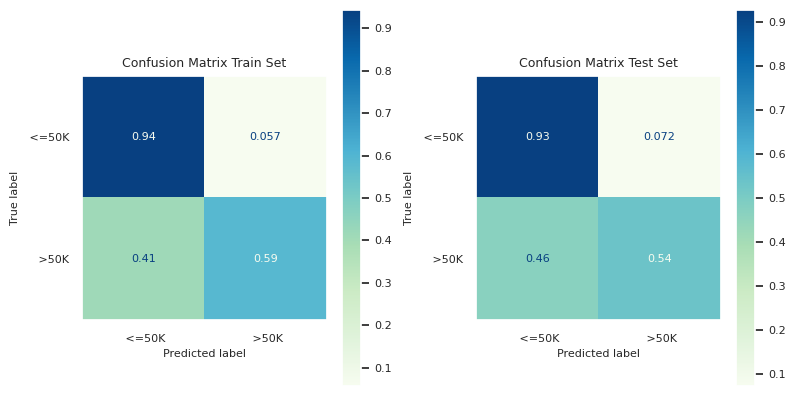

In [ ]:
svm = SVC(kernel='rbf', C=C_rbf_max, cache_size=1000, random_state=42)
svm.fit(X_train_encoded,y_train)

y_pred_train = svm.predict(X_train_encoded)
y_pred_test = svm.predict(X_test_encoded)
print('Train Set Report:')
print(classification_report(y_train, y_pred_train))
print('Test Set Report:')
print(classification_report(y_test, y_pred_test))

fig, ax = plt.subplots(figsize=(8,4), ncols=2, nrows=1)

cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le_class.classes_)
disp_train = disp_train.plot(ax=ax[0],cmap=plt.cm.GnBu)
ax[0].set_title('Confusion Matrix Train Set', size=9)

cm_test = confusion_matrix(y_test, y_pred_test, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le_class.classes_)
disp_test = disp_test.plot(ax=ax[1],cmap=plt.cm.GnBu)
ax[1].set_title('Confusion Matrix Test Set', size=9)

fig.tight_layout()
plt.show()

# P6. Kerneles

Diseñe y aplique un método que permita seleccionar un kernel apropiado para la SVM.

*   Implemente un método que permita elegir uno de dos kerneles no lineales posibles empleando valores por defecto para todos los demás parámetros.

*   Implemente un método que permita elegir simultáneamente un valor para C y para el hiper-parámetro más importante del kernel seleccionado en el punto anterior. ¿Es posible sintonizar los valores de estos dos parámetros de modo independiente?

*  Compare el efecto sobre sus estrategias de la idea de limitar la optimización del modelo, discutiendo lo que observa (Hint: la optimización de la SVM se puede relajar modificando los parámetros tol y max_iter).

*   Estudie el desempeño detallado del mejor modelo seleccionado en esta sección.  

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['rbf', 'poly']
}

svm = SVC()

grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_encoded, y_train)

print("Best hyperparameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_encoded, y_test)
print("Test set accuracy:", test_accuracy)

Best hyperparameters: {'kernel': 'poly'}
Test set accuracy: 0.8350990327038231


In [ ]:
from sklearn.model_selection import GridSearchCV

params_model = grid_search.best_params_
svm = SVC(kernel=params_model['kernel'])

if params_model['kernel'] == 'poly':
    param_grid_poly = {
        'C': np.logspace(-2, 3, num=6, endpoint=True, base=10.0),
        'degree': range(2,7)
    }

    svm_poly = SVC(kernel='poly', random_state=42)

    grid_search = GridSearchCV(svm_poly, param_grid_poly, cv=5, n_jobs=-1)
    grid_search.fit(X_train_encoded, y_train)

    params_model = grid_search.best_params_
    params_model['kernel'] = 'poly'

    print("Best hyperparameters:", params_model)
    best_model = grid_search.best_estimator_
    test_accuracy = best_model.score(X_test_encoded, y_test)
    print("Test set accuracy:", test_accuracy)
else:
    param_grid_rbf = {
        'C': np.logspace(-2, 3, num=6, endpoint=True, base=10.0),
        'gamma': np.logspace(-2, 3, num=6, endpoint=True, base=10.0),
    }

    svm_poly = SVC(kernel='rbf', random_state=42)

    grid_search = GridSearchCV(svm_poly, param_grid_rbf, cv=5, n_jobs=-1)
    grid_search.fit(X_train_encoded, y_train)

    params_model = grid_search.best_params_
    params_model['kernel'] = 'rbf'

    print("Best hyperparameters:", params_model)
    best_model = grid_search.best_estimator_
    test_accuracy = best_model.score(X_test_encoded, y_test)
    print("Test set accuracy:", test_accuracy)

Best hyperparameters: {'C': 10.0, 'degree': 2, 'kernel': 'poly'}
Test set accuracy: 0.8381698142177184


In [ ]:
tol_kernels = []
tol_test_accuracy = []
tolerance = np.logspace(-4,0, num=5, endpoint=True, base=10.0)[::-1]
for t in tolerance:
    param_grid = {
        'kernel': ['rbf', 'poly']
    }
    svm = SVC(tol=t, random_state=42)
    grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train_encoded, y_train)

    tol_kernels.append(grid_search.best_params_['kernel'])
    tol_test_accuracy.append(grid_search.best_estimator_.score(X_test_encoded, y_test))
    print('Done tol:', t)


iter_kernels = []
iter_test_accuracy = []
max_iterations = [50, 100, 250, 500, 1000]
for i in max_iterations:
    param_grid = {
        'kernel': ['rbf', 'poly']
    }
    svm = SVC(max_iter=i, random_state=42)
    grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train_encoded, y_train)

    iter_kernels.append(grid_search.best_params_['kernel'])
    iter_test_accuracy.append(grid_search.best_estimator_.score(X_test_encoded, y_test))
    print('Done max_iter:', i)

Done tol: 1.0
Done tol: 0.1
Done tol: 0.01
Done tol: 0.001
Done tol: 0.0001
Done max_iter: 50
Done max_iter: 100
Done max_iter: 250
Done max_iter: 500
Done max_iter: 1000


Text(0.5, 1.0, 'Test accuracy vs max iterations')

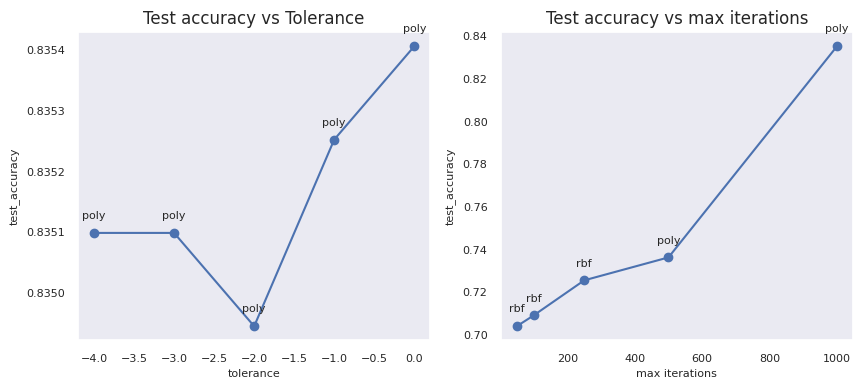

In [ ]:
fig, ax = plt.subplots(figsize=(10,4), ncols=2, nrows=1)

ax[0].plot(np.log10(tolerance), tol_test_accuracy, marker='o', linestyle='-', color='b')


for i, txt in enumerate(tol_kernels):
    ax[0].annotate(txt, (np.log10(tolerance)[i], tol_test_accuracy[i]), textcoords="offset points", xytext=(0, 10), ha='center')


ax[0].set_xlabel('tolerance')
ax[0].set_ylabel('test_accuracy')
ax[0].set_title('Test accuracy vs Tolerance')


ax[1].plot(max_iterations, iter_test_accuracy, marker='o', linestyle='-', color='b')

for i, txt in enumerate(iter_kernels):
    ax[1].annotate(txt, (max_iterations[i], iter_test_accuracy[i]), textcoords="offset points", xytext=(0, 10), ha='center')

ax[1].set_xlabel('max iterations')
ax[1].set_ylabel('test_accuracy')
ax[1].set_title('Test accuracy vs max iterations')

SVC model: {'C': 10.0, 'degree': 2, 'kernel': 'poly'}
Train Set Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3955
           1       0.81      0.69      0.75      1254

    accuracy                           0.89      5209
   macro avg       0.86      0.82      0.84      5209
weighted avg       0.88      0.89      0.88      5209

Test Set Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4945
           1       0.70      0.57      0.63      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.75      0.76      6513
weighted avg       0.83      0.84      0.83      6513



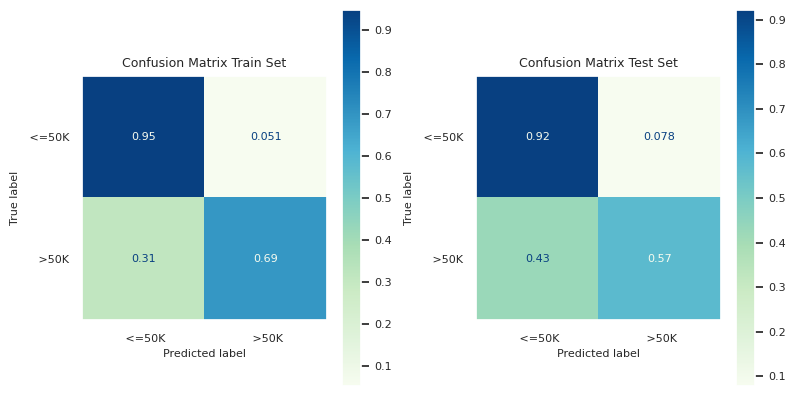

In [ ]:
print('SVC model:', params_model)
if params_model['kernel'] == 'poly':
    svm_non_linear = SVC(C=params_model['C'], kernel='poly', degree=params_model['degree'])
else:
    svm_non_linear = SVC(C=params_model['C'], kernel='rbf', gamma=params_model['gamma'])

svm_non_linear.fit(X_train_encoded, y_train)

y_pred_train = svm_non_linear.predict(X_train_encoded)
y_pred_test = svm_non_linear.predict(X_test_encoded)

print('Train Set Report:')
print(classification_report(y_train, y_pred_train))
print('Test Set Report:')
print(classification_report(y_test, y_pred_test))

fig, ax = plt.subplots(figsize=(8,4), ncols=2, nrows=1)

cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le_class.classes_)
disp_train = disp_train.plot(ax=ax[0],cmap=plt.cm.GnBu)
ax[0].set_title('Confusion Matrix Train Set', size=9)

cm_test = confusion_matrix(y_test, y_pred_test, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le_class.classes_)
disp_test = disp_test.plot(ax=ax[1],cmap=plt.cm.GnBu)
ax[1].set_title('Confusion Matrix Test Set', size=9)

fig.tight_layout()
plt.show()

# P7. SVM & Atributos

Estudie qué características son más relevantes para la SVM.

*   Aprovechando la linealidad de la primera SVM entrenada, determine cuáles son las 20 características reciben mayor "peso" en la SVM.

*   Proponga una técnica que permita evaluar explícitamente la importancia de un atributo al entrenar una SVM, discutiendo las limitaciones esperadas.

*   Aplique su método para determinar las 20 características más importantes para la SVM lineal y compare con el resultado del método anterior.

*   Aplique su método para determinar las 20 características más importantes para alguna de las (buenas) SVM no lineales entrenadas con anterioridad. Compare con los resultados obtenidos para la SVM lineal.

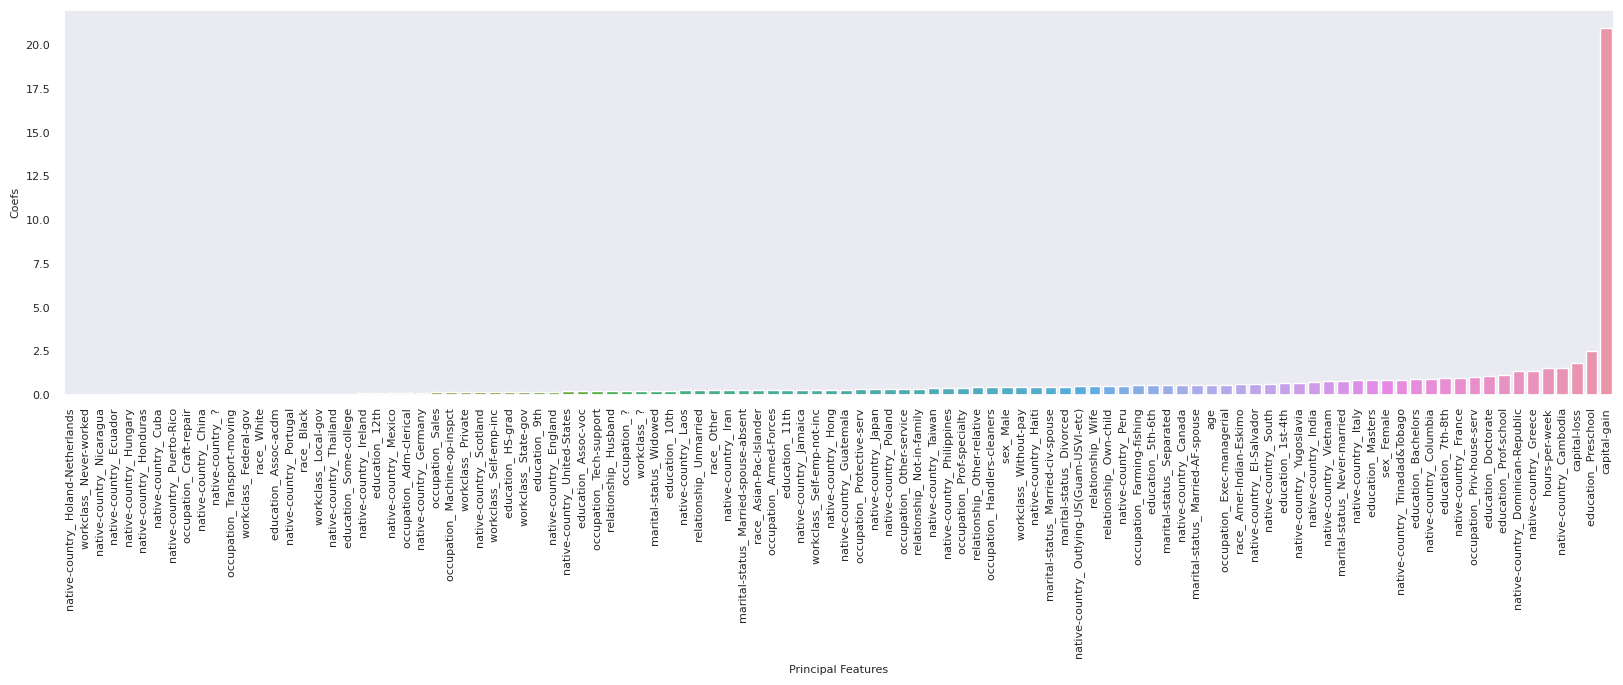

In [ ]:
idx = np.argsort(np.abs(svm_linear.coef_[0]))
# idx = idx[:20]
pf_by_coefs = pd.DataFrame(
    {
    'Principal Features': X_train_encoded.columns[idx].tolist(),
    'Coefs': np.abs(svm_linear.coef_).reshape(svm_linear.coef_[0].shape[0])[idx]
    }
)

fig, axes = plt.subplots(figsize=(20,5), nrows=1, ncols=1)
sns.barplot(data=pf_by_coefs, x='Principal Features', y='Coefs', ax=axes)
_=plt.xticks(rotation=90)


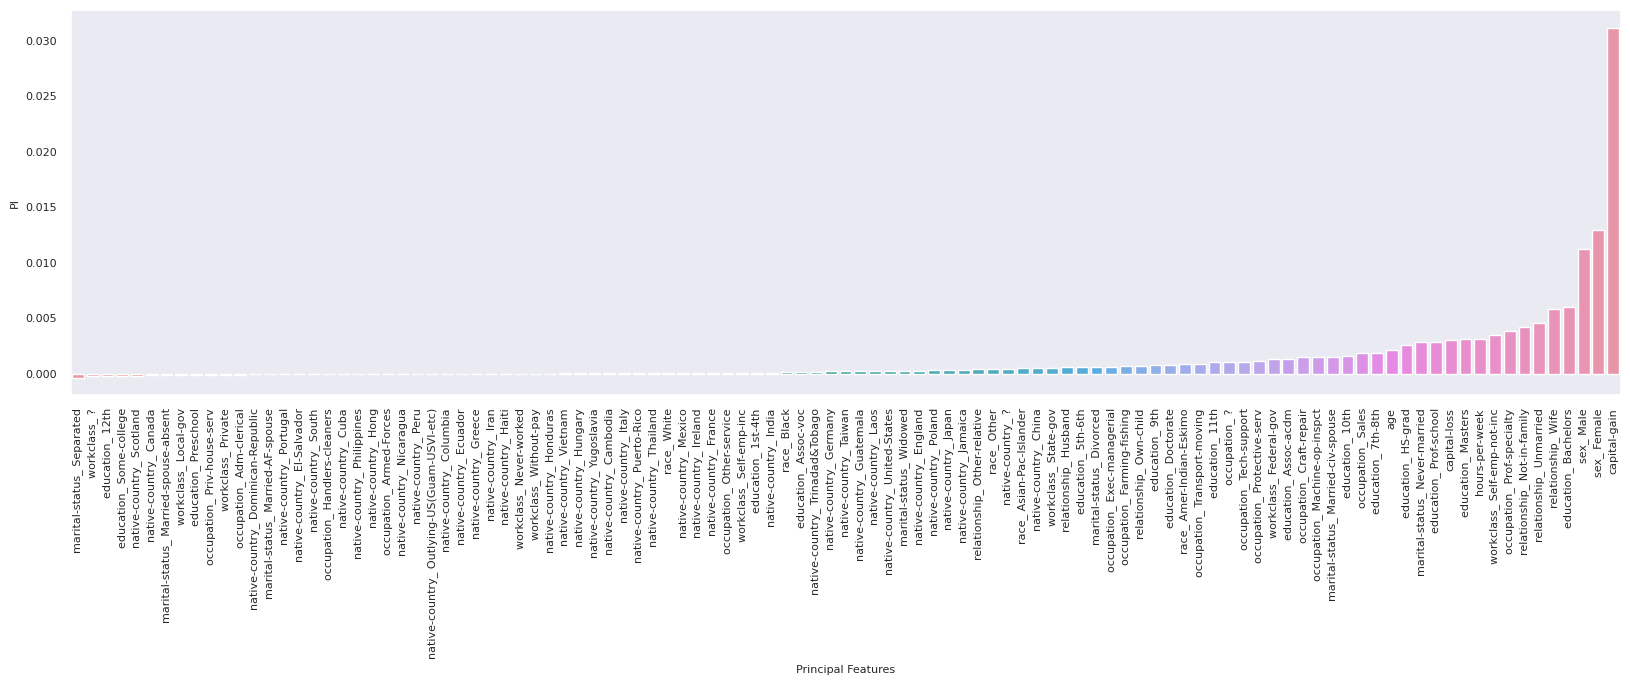

In [ ]:
from sklearn.inspection import permutation_importance

scores = permutation_importance(svm_linear, X_train_encoded, y_train, n_repeats=10,random_state=0)
idx = np.argsort(scores.importances_mean)

# idx = idx[:20]
pf_by_pi = pd.DataFrame(
    {
    'Principal Features': X_train_encoded.columns[idx].tolist(),
    'PI': (scores.importances_mean).reshape(scores.importances_mean.shape[0])[idx]
    }
)

fig, axes = plt.subplots(figsize=(20,5), nrows=1, ncols=1)
sns.barplot(data=pf_by_pi, x='Principal Features', y='PI', ax=axes)
_=plt.xticks(rotation=90)


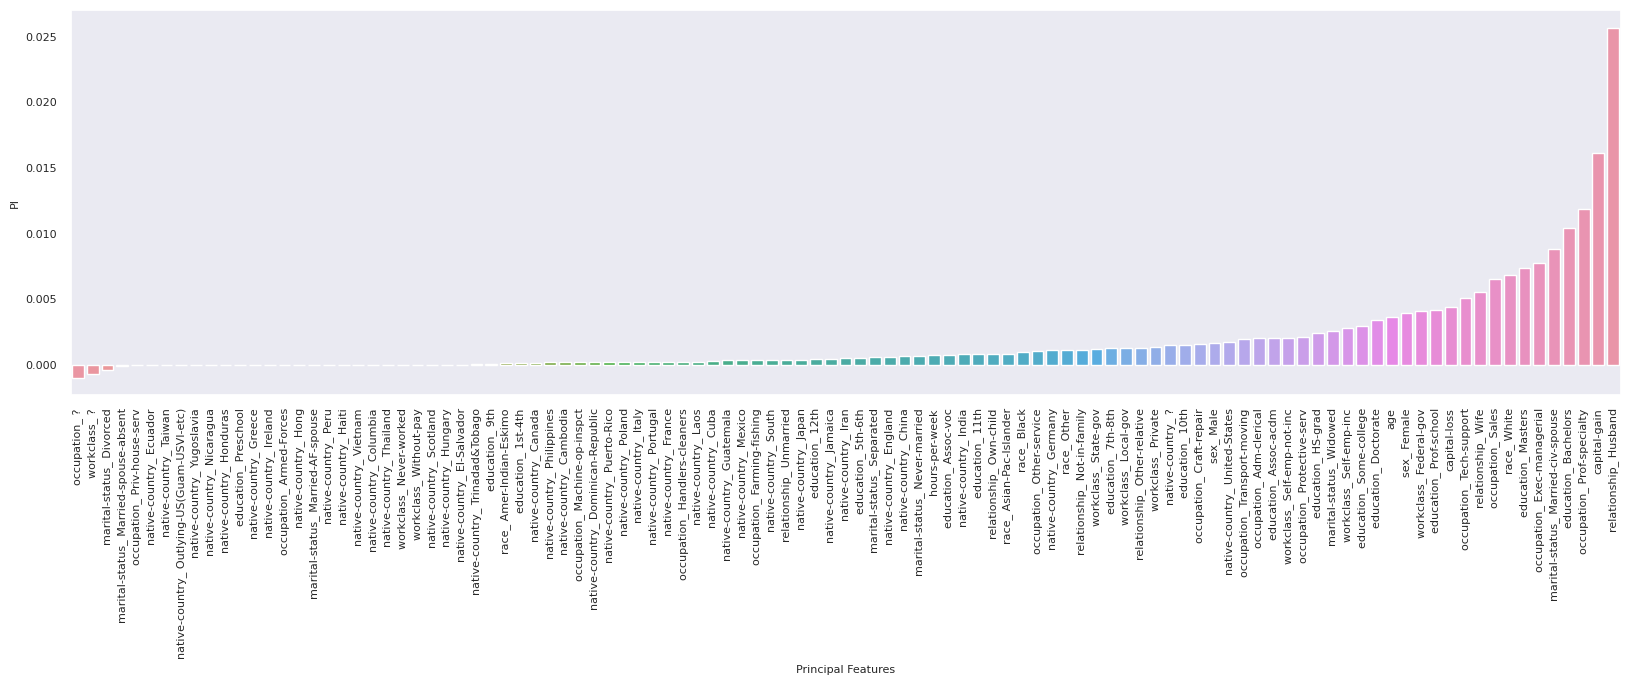

In [ ]:
scores = permutation_importance(svm_non_linear, X_train_encoded, y_train, n_repeats=10,random_state=0)
idx = np.argsort(scores.importances_mean)

idx = idx[:20]
pf_by_pi = pd.DataFrame(
    {
    'Principal Features': X_train_encoded.columns[idx].tolist(),
    'PI': (scores.importances_mean).reshape(scores.importances_mean.shape[0])[idx]
    }
)

fig, axes = plt.subplots(figsize=(20,5), nrows=1, ncols=1)
sns.barplot(data=pf_by_pi, x='Principal Features', y='PI', ax=axes)
_=plt.xticks(rotation=90)

# P8. Árboles

Estudie el desempeño de un árbol de clasificación en el problema.


*   Entrene un árbol de clasificación cuyo crecimiento esté guiado por la minimización de la entropía. Usando parámetros por defecto, mida la capacidad de generalización del modelo resultante.

*   Limitando la profundidad a 4 niveles, entrene y visualice un árbol clasificación explicando la forma en que éste asigna una clase a un dato de entrada.

*   Explique la diferencia entre entrenar el árbol usando el índice de Gini en lugar de la entropía. Mida cuál de los dos árboles obtiene una mayor capacidad de generalización.

R: Son mediciones distintas para decidir el split de una hoja; Gini mide la pureza de la hoja, mientras que entropy mide la incertidumbre. Sin embargo, observando el rendimiento empírico de los modelos, no hay mayor diferencia entre los dos criterios tanto en el train set, como en el test set.

*   Proponga un método que permita elegir entre uno de los dos criterios de crecimiento estudiados de modo de minimizar el error de predicción. Sólo con fines educativos, verifique si su método hace la elección correcta, midiendo el error sobre el conjunto de pruebas.

R: Mediante Cross-Validation, se estudiará el mejor modelo.

*   Como habrán notado las estudiantes curiosas, sklearn no permite entrenar apropiadamente un árbol de decisión con atributos categóricos (si bien el modelo ciertamente puede hacerlo). Modifique la codificación realizada en en P3 usando un OrdinalEncoder para los atributos categóricos en vez de un OneHotEncoder. Entrene un árbol (profundidad máxima 4), visualice el resultado, y explique porqué este método no es correcto.

R: OrdinalEncoder no es apropiado pues supone un orden entre los valores del atributo, además que decidir sobre variables categóricas consiste en decidir un valor concreto sobre la variable, y no un rango como sucede en los atributos continuos.

*   Estudie el desempeño detallado del modelo determinando si exhibe una mayor dificultad con alguna de las clases.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_model.fit(X_train_encoded,y_train)

print('Entropy Tree Classifier')
print('Train accuracy   :', tree_model.score(X_train_encoded, y_train))
print('Test accuracy    :', tree_model.score(X_test_encoded, y_test))

Entropy Tree Classifier
Train accuracy   : 0.9915530812056057
Test accuracy    : 0.8162137263933671


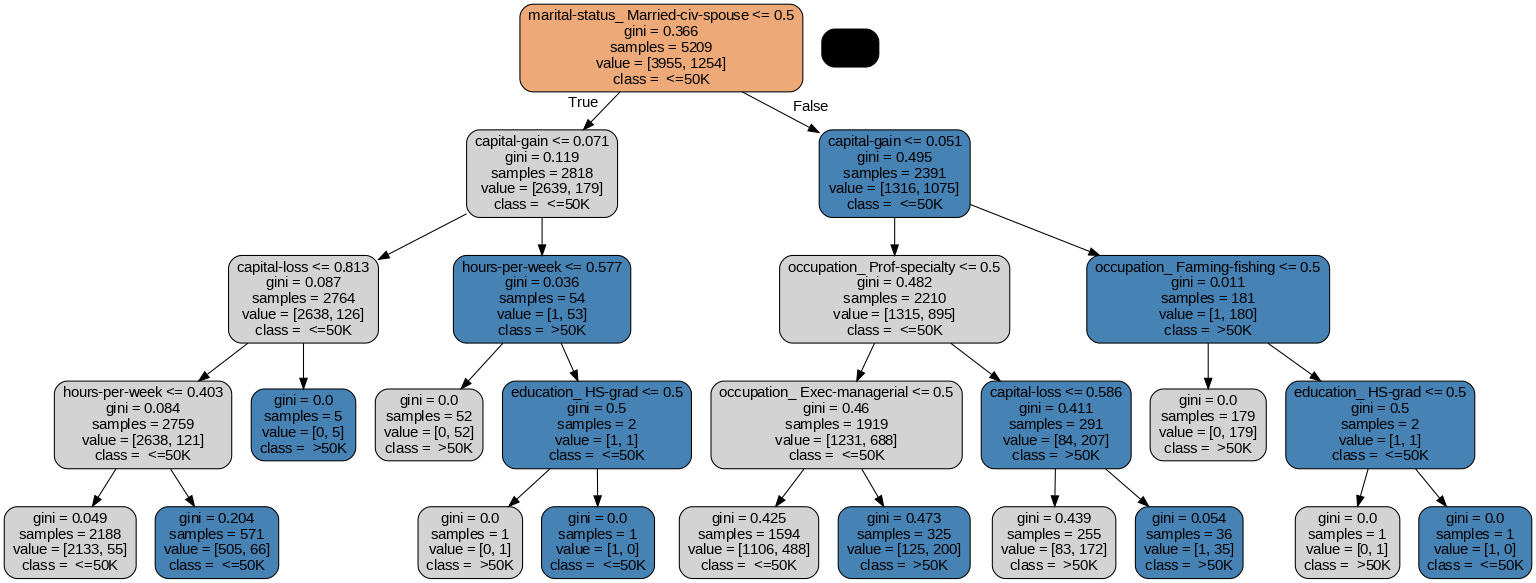

In [ ]:
from sklearn import tree
from IPython.display import Image as PImage
from PIL import Image, ImageDraw, ImageFont
from pydotplus import graphviz
import pydotplus
import collections

clf =  DecisionTreeClassifier(max_depth = 4, random_state=42)
clf.fit(X_train_encoded,y_train)


dot_data = tree.export_graphviz(clf, out_file="mi_arbol.dot", feature_names = X_train_encoded.columns,
                              class_names = le_class.classes_, rounded = True, filled= True )

graph = pydotplus.graph_from_dot_file("mi_arbol.dot")

nodes = graph.get_node_list()
edges = graph.get_edge_list()

colors = ('lightgray', 'steelblue') #'rosybrown')
edges = collections.defaultdict(list)

for edge in graph.get_edge_list():
    edges[edge.get_source()].append(int(edge.get_destination()))

for edge in edges:
    edges[edge].sort()
    for i in range(2):
        dest = graph.get_node(str(edges[edge][i]))[0]
        dest.set_fillcolor(colors[i])

graph.write_png('mi_arbol.png')
graph.set_size('16,16!"')
graph.set_fontname
graph.write_png('mi_arbol_resized.png')


img = Image.open("mi_arbol_resized.png")

print("\n\n")
PImage("mi_arbol_resized.png")

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

tree_en = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_gi = DecisionTreeClassifier(criterion='gini', random_state=42)

tree_en.fit(X_train_encoded, y_train)
tree_gi.fit(X_train_encoded, y_train)

print('Train Accuracy')
print('Tree Entropy :', tree_en.score(X_train_encoded, y_train))
print('Tree Gini    :', tree_gi.score(X_train_encoded, y_train))
print('\nTest Accuracy')
print('Tree Entropy :', tree_en.score(X_test_encoded, y_test))
print('Tree Gini    :', tree_gi.score(X_test_encoded, y_test))

Train Accuracy
Tree Entropy : 0.9915530812056057
Tree Gini    : 0.9915530812056057

Test Accuracy
Tree Entropy : 0.8162137263933671
Tree Gini    : 0.814985413787809


In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'criterion': ['entropy', 'gini']
}

tree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(tree, param_grid, cv=5, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train_encoded, y_train)

print('Best hyperparameters:', grid_search.best_params_)

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test_encoded, y_test)
print('CV score mejor modelo        :', grid_search.best_score_)
print('Test accuracy mejor modelo   :', test_accuracy)

tree_en = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_gi = DecisionTreeClassifier(criterion='gini', random_state=42)

tree_en.fit(X_train_encoded, y_train)
tree_gi.fit(X_train_encoded, y_train)

print('\nTest accuracy')
print('Entropy  :', tree_en.score(X_test_encoded, y_test))
print('Gini     :', tree_gi.score(X_test_encoded, y_test))

Best hyperparameters: {'criterion': 'entropy'}
CV score mejor modelo        : 0.8147438698578992
Test accuracy mejor modelo   : 0.8162137263933671

Test accuracy
Entropy  : 0.8162137263933671
Gini     : 0.814985413787809


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler

continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

X_train_ord_encoded = data_train[continuous_features]
X_test_ord_encoded = data_test[continuous_features]

continuous_scaler = MinMaxScaler()
continuous_scaler.fit(X_train_ord_encoded)

X_train_ord_encoded = pd.DataFrame(continuous_scaler.transform(X_train_ord_encoded),columns=continuous_features)
X_test_ord_encoded = pd.DataFrame(continuous_scaler.transform(X_test_ord_encoded),columns=continuous_features)

categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']

categorical_encoder = OrdinalEncoder()
cat_X_train_ord_encoded = categorical_encoder.fit_transform(data_train[categorical_features])
cat_X_train_ord_encoded = pd.DataFrame(cat_X_train_ord_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_train_ord_encoded = pd.concat([X_train_ord_encoded,cat_X_train_ord_encoded],axis=1)
cat_X_test_ord_encoded = categorical_encoder.transform(data_test[categorical_features])
cat_X_test_ord_encoded = pd.DataFrame(cat_X_test_ord_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_test_ord_encoded = pd.concat([X_test_ord_encoded,cat_X_test_ord_encoded],axis=1)

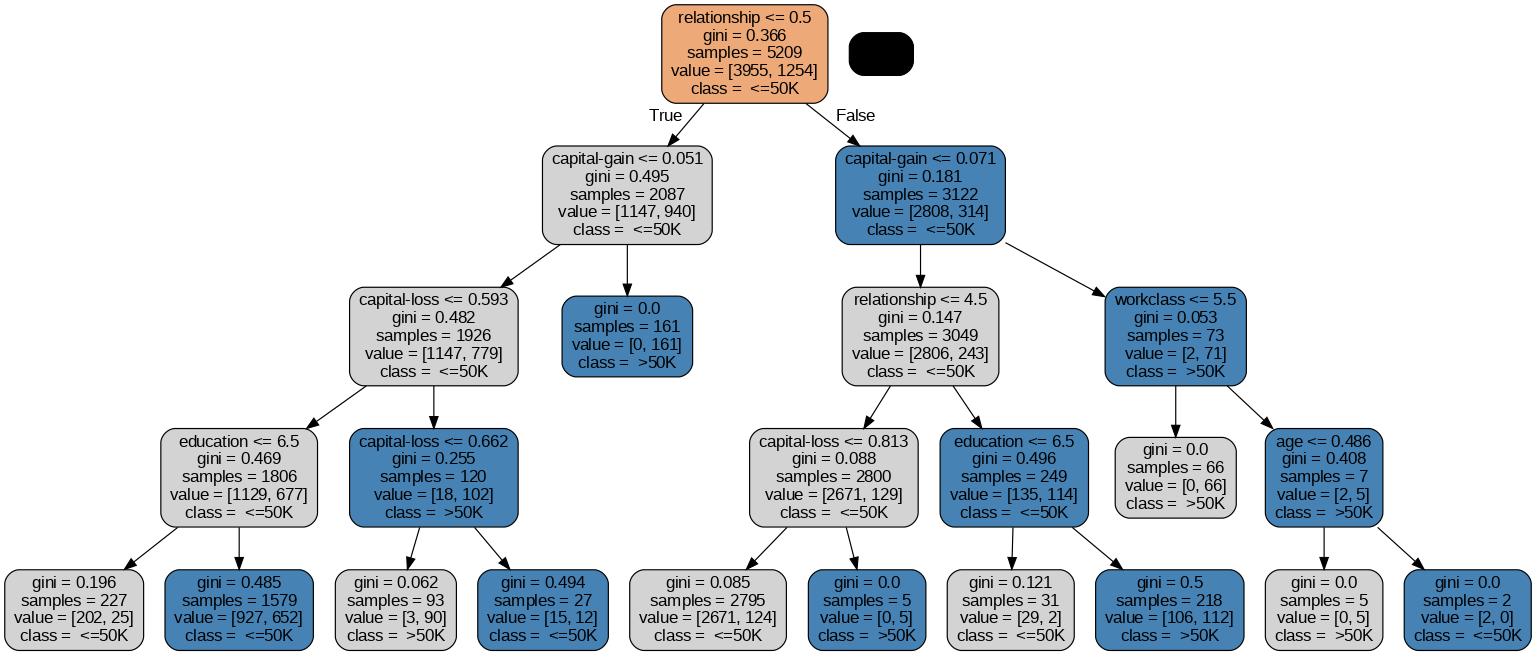

In [ ]:
from sklearn import tree
from IPython.display import Image as PImage
from PIL import Image, ImageDraw, ImageFont
from pydotplus import graphviz
import pydotplus
import collections

clf2 =  DecisionTreeClassifier(max_depth = 4)
clf2.fit(X_train_ord_encoded,y_train)


dot_data = tree.export_graphviz(clf2, out_file="mi_arbol2.dot", feature_names = X_train_ord_encoded.columns,
                              class_names = le_class.classes_, rounded = True, filled= True )

graph = pydotplus.graph_from_dot_file("mi_arbol2.dot")

nodes = graph.get_node_list()
edges = graph.get_edge_list()

colors = ('lightgray', 'steelblue') #'rosybrown')
edges = collections.defaultdict(list)

for edge in graph.get_edge_list():
    edges[edge.get_source()].append(int(edge.get_destination()))

for edge in edges:
    edges[edge].sort()
    for i in range(2):
        dest = graph.get_node(str(edges[edge][i]))[0]
        dest.set_fillcolor(colors[i])

graph.write_png('mi_arbol2.png')
graph.set_size('16,16!"')
graph.set_fontname
graph.write_png('mi_arbol2_resized.png')


img = Image.open("mi_arbol2_resized.png")

print("\n\n")
PImage("mi_arbol2_resized.png")

Train Set Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      3955
           1       0.80      0.35      0.49      1254

    accuracy                           0.82      5209
   macro avg       0.81      0.66      0.69      5209
weighted avg       0.82      0.82      0.80      5209

Test Set Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      4945
           1       0.79      0.35      0.49      1568

    accuracy                           0.82      6513
   macro avg       0.81      0.66      0.69      6513
weighted avg       0.82      0.82      0.79      6513



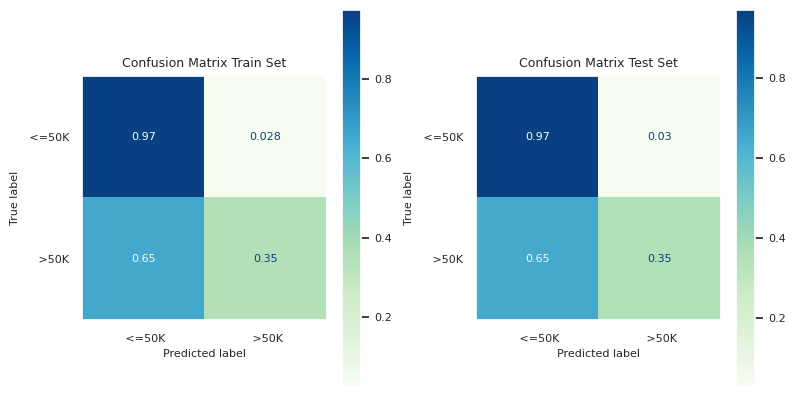

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = clf2.predict(X_train_ord_encoded)
y_pred_test = clf2.predict(X_test_ord_encoded)
print('Train Set Report:')
print(classification_report(y_train, y_pred_train))
print('Test Set Report:')
print(classification_report(y_test, y_pred_test))

fig, ax = plt.subplots(figsize=(8,4), ncols=2, nrows=1)

cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le_class.classes_)
disp_train = disp_train.plot(ax=ax[0],cmap=plt.cm.GnBu)
ax[0].set_title('Confusion Matrix Train Set', size=9)

cm_test = confusion_matrix(y_test, y_pred_test, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le_class.classes_)
disp_test = disp_test.plot(ax=ax[1],cmap=plt.cm.GnBu)
ax[1].set_title('Confusion Matrix Test Set', size=9)

fig.tight_layout()
plt.show()

Train Set Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3955
           1       0.99      0.97      0.98      1254

    accuracy                           0.99      5209
   macro avg       0.99      0.98      0.99      5209
weighted avg       0.99      0.99      0.99      5209

Test Set Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4945
           1       0.62      0.62      0.62      1568

    accuracy                           0.82      6513
   macro avg       0.75      0.75      0.75      6513
weighted avg       0.82      0.82      0.82      6513



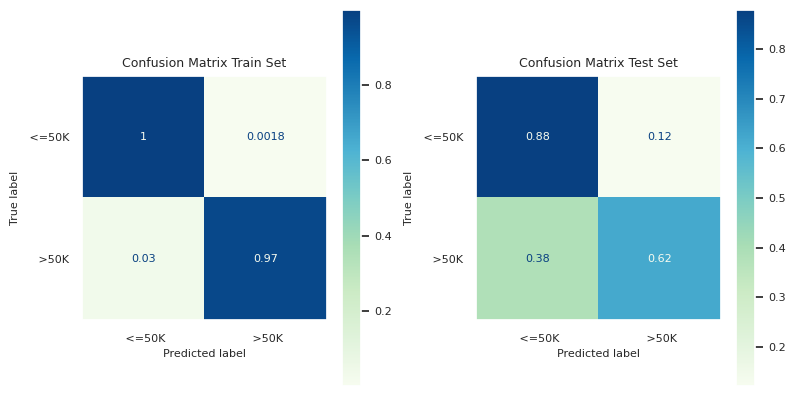

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred_train = tree_en.predict(X_train_encoded)
y_pred_test = tree_en.predict(X_test_encoded)
print('Train Set Report:')
print(classification_report(y_train, y_pred_train))
print('Test Set Report:')
print(classification_report(y_test, y_pred_test))

fig, ax = plt.subplots(figsize=(8,4), ncols=2, nrows=1)

cm_train = confusion_matrix(y_train, y_pred_train, normalize='true')
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=le_class.classes_)
disp_train = disp_train.plot(ax=ax[0],cmap=plt.cm.GnBu)
ax[0].set_title('Confusion Matrix Train Set', size=9)

cm_test = confusion_matrix(y_test, y_pred_test, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=le_class.classes_)
disp_test = disp_test.plot(ax=ax[1],cmap=plt.cm.GnBu)
ax[1].set_title('Confusion Matrix Test Set', size=9)

fig.tight_layout()
plt.show()

# P9. Árboles Regularizados

Evalúe diferentes métodos de regularización para árboles.

*   Evalúe el efecto de limitar la profundidad máxima del árbol sobre el error de entrenamiento y sobre la capacidad de generalización del modelo.

*   Proponga y evalúe experimentalmente un método que le permita seleccionar un valor adecuado de profundidad máxima.

*   Usando parámetros por defecto para cualquier otro parámetro, evalúe el efecto de aplicar el mecanismo de poda de CART sobre el error de entrenamiento y sobre la capacidad de generalización del modelo. Estudie el efecto de diferentes valores para el parámetro de regularización.

*   Proponga un método que permita elegir un valor apropiado para el parámetro de regularización necesario para ejecutar el método de poda de CART.

*   Compare experimentalmente los tres métodos clásicos para regularizar un árbol: (i) limitar la profundidad, (ii) pedir un soporte mínimo por hoja, y (iii) podar el árbol.

In [ ]:
# Profundidad Máxima
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

cv = KFold(n_splits=10)

cv_accuracies = []
train_accuracies = []
test_accuracies = []
cv_std = []

depth_range = range(1,21)

depth_to_idx = {depth_range[idx] : idx for idx in range(len(depth_range))}

for depth in depth_range:

    fold_accuracy = []
    tree_model = DecisionTreeClassifier(max_depth = depth)

    for train_fold, valid_fold in cv.split(X_train_encoded):

        x_train_fold = X_train_encoded.iloc[train_fold]
        x_val_fold = X_train_encoded.iloc[valid_fold]
        y_train_fold = y_train[train_fold]
        y_val_fold = y_train[valid_fold]

        tree_model.fit(x_train_fold, y_train_fold)
        valid_acc = tree_model.score(x_val_fold, y_val_fold)
        fold_accuracy.append(valid_acc)

    cv_acc = sum(fold_accuracy)/len(fold_accuracy)
    cv_accuracies.append(cv_acc)
    cv_std.append(np.array(fold_accuracy).std())

    tree_model = DecisionTreeClassifier(max_depth = depth)

    tree_model.fit(X_train_encoded, y_train)

    train_acc = tree_model.score(X_train_encoded,y_train)
    test_acc = tree_model.score(X_test_encoded,y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print("done depth: ", depth)

done depth:  1
done depth:  2
done depth:  3
done depth:  4
done depth:  5
done depth:  6
done depth:  7
done depth:  8
done depth:  9
done depth:  10
done depth:  11
done depth:  12
done depth:  13
done depth:  14
done depth:  15
done depth:  16
done depth:  17
done depth:  18
done depth:  19
done depth:  20


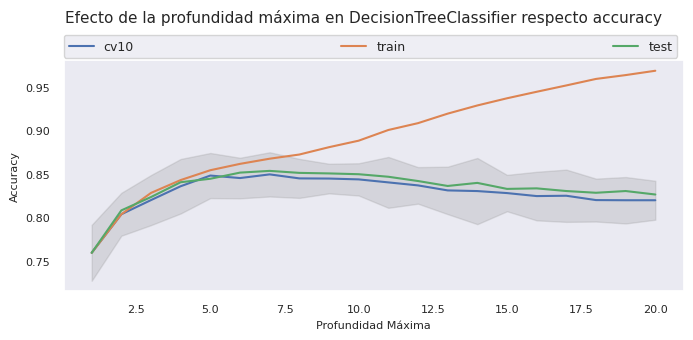

In [ ]:
cv_accuracies = np.array(cv_accuracies)
cv_std = np.array(cv_std)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(depth_range,cv_accuracies,label='cv10')
ax.plot(depth_range,train_accuracies,label='train')
ax.plot(depth_range,test_accuracies,label='test')
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0., fontsize=9)
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0.,fontsize=9)
plt.fill_between(depth_range, cv_accuracies-2*cv_std, cv_accuracies+2*cv_std,color='gray', alpha=0.2)

ax.set_xlabel("Profundidad Máxima")
ax.set_ylabel("Accuracy")
fig.suptitle('Efecto de la profundidad máxima en DecisionTreeClassifier respecto accuracy', y=1.05, size=11)
plt.show()


In [ ]:
cv_accuracies = np.array(cv_accuracies)
idx_max = np.argmax(cv_accuracies)

result_prof = {
    'parameter': depth_range[idx_max],
    'cv_accuracy': cv_accuracies[idx_max],
    'test_accuracy': test_accuracies[idx_max],
    'train accuracy': train_accuracies[idx_max]
}


In [ ]:
result_prof

{'parameter': 7,
 'cv_accuracy': 0.8494932083271813,
 'test_accuracy': 0.8535237217871948,
 'train accuracy': 0.8675369552697255}

Numero de nodos en el ultimo arbol es: 3 con ccp_alpha: 0.07402901413600205


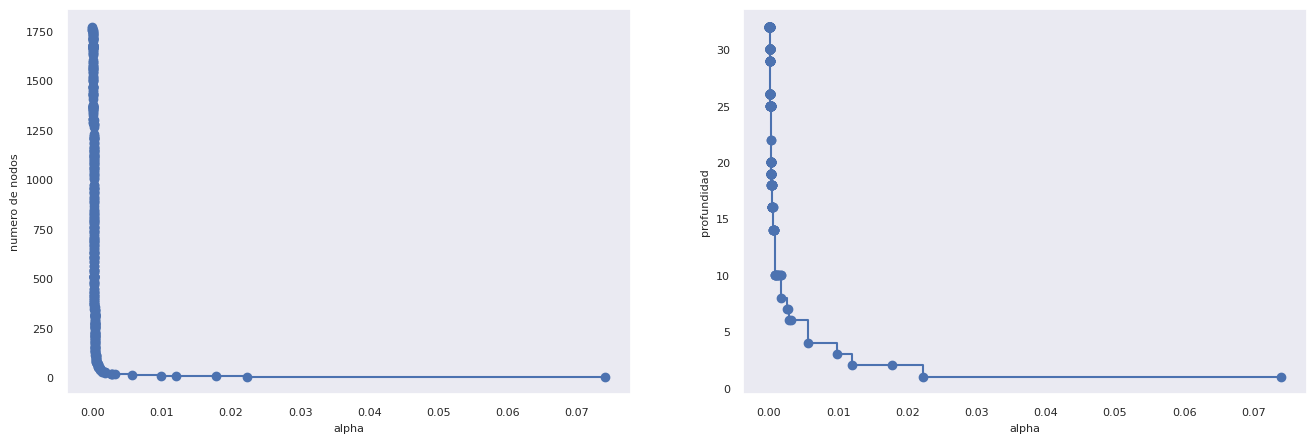

In [ ]:
# Poda de CART
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
path = model.cost_complexity_pruning_path(X_train_encoded, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

trees = []
for ccp_alpha in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha)
    tree.fit(X_train_encoded, y_train)
    trees.append(tree)

print("Numero de nodos en el ultimo arbol es: {} con ccp_alpha: {}".format(trees[-1].tree_.node_count, ccp_alphas[-1]))

node_counts = [tree.tree_.node_count for tree in trees]
depth = [tree.tree_.max_depth for tree in trees]

fig, ax = plt.subplots(figsize=(16, 5),ncols=2,nrows=1)

ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("numero de nodos")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("profundidad")

plt.show()

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier


cv = KFold(n_splits=10)

cv_accuracies = []
train_accuracies = []
test_accuracies = []

for ccp_alpha in ccp_alphas:

    fold_accuracy = []
    tree_model = DecisionTreeClassifier(ccp_alpha=ccp_alpha)

    for train_fold, valid_fold in cv.split(X_train_encoded):

        x_train_fold = X_train_encoded.iloc[train_fold]
        x_val_fold = X_train_encoded.iloc[valid_fold]
        y_train_fold = y_train[train_fold]
        y_val_fold = y_train[valid_fold]

        tree_model.fit(x_train_fold, y_train_fold)
        valid_acc = tree_model.score(x_val_fold, y_val_fold)
        fold_accuracy.append(valid_acc)

    cv_acc = sum(fold_accuracy)/len(fold_accuracy)
    cv_accuracies.append(cv_acc)

    tree_model = DecisionTreeClassifier(ccp_alpha=ccp_alpha)

    tree_model.fit(X_train_encoded, y_train)

    train_acc = tree_model.score(X_train_encoded,y_train)
    test_acc = tree_model.score(X_test_encoded,y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


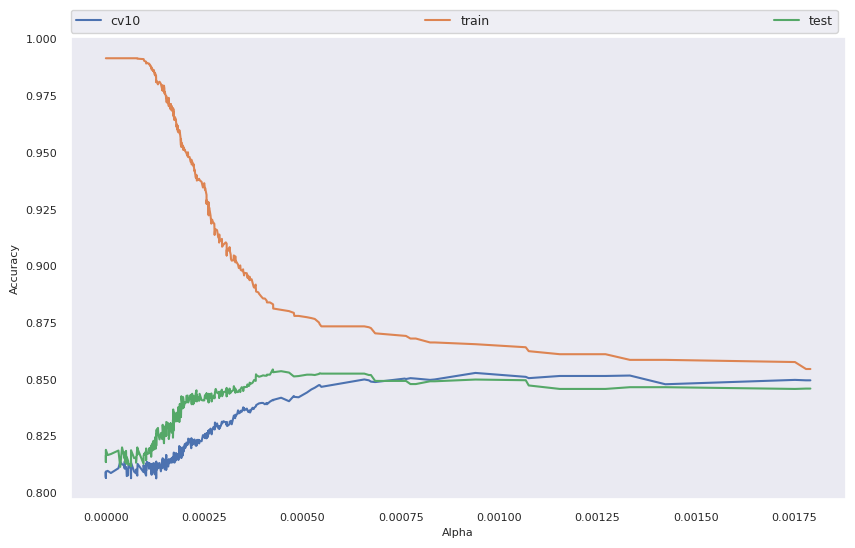

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

init=0
end=-10

ax.plot(ccp_alphas[init:end],cv_accuracies[init:end],label='cv10')
ax.plot(ccp_alphas[init:end],train_accuracies[init:end],label='train')
ax.plot(ccp_alphas[init:end],test_accuracies[init:end],label='test')
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0., fontsize=9)
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0., fontsize=9)
ax.set_xlabel("Alpha")
ax.set_ylabel("Accuracy")
plt.show()


In [ ]:
cv_accuracies = np.array(cv_accuracies)
idx_max = np.argmax(cv_accuracies)

result_poda = {
    'parameter': ccp_alphas[idx_max],
    'cv_accuracy': cv_accuracies[idx_max],
    'test_accuracy': test_accuracies[idx_max],
    'train accuracy': train_accuracies[idx_max]
}

In [ ]:
# Soporte mínimo en hojas
cv = KFold(n_splits=10)

cv_accuracies = []
train_accuracies = []
test_accuracies = []
cv_std = []

# depth_range = range(1,21)
min_supp = np.linspace(0.02, 0.5, num=25)
supp_to_idx = {min_supp[idx] : idx for idx in range(len(min_supp))}

for supp in min_supp:

    fold_accuracy = []
    tree_model = DecisionTreeClassifier(min_samples_leaf = supp)

    for train_fold, valid_fold in cv.split(X_train_encoded):

        x_train_fold = X_train_encoded.iloc[train_fold]
        x_val_fold = X_train_encoded.iloc[valid_fold]
        y_train_fold = y_train[train_fold]
        y_val_fold = y_train[valid_fold]

        tree_model.fit(x_train_fold, y_train_fold)
        valid_acc = tree_model.score(x_val_fold, y_val_fold)
        fold_accuracy.append(valid_acc)

    cv_acc = sum(fold_accuracy)/len(fold_accuracy)
    cv_accuracies.append(cv_acc)
    cv_std.append(np.array(fold_accuracy).std())

    tree_model = DecisionTreeClassifier(min_samples_leaf = supp)

    tree_model.fit(X_train_encoded, y_train)

    train_acc = tree_model.score(X_train_encoded,y_train)
    test_acc = tree_model.score(X_test_encoded,y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print("done min_supp_leaf: ", supp)

done min_supp_leaf:  0.02
done min_supp_leaf:  0.04
done min_supp_leaf:  0.06
done min_supp_leaf:  0.08
done min_supp_leaf:  0.1
done min_supp_leaf:  0.12000000000000001
done min_supp_leaf:  0.13999999999999999
done min_supp_leaf:  0.16
done min_supp_leaf:  0.18
done min_supp_leaf:  0.19999999999999998
done min_supp_leaf:  0.22
done min_supp_leaf:  0.24
done min_supp_leaf:  0.26
done min_supp_leaf:  0.28
done min_supp_leaf:  0.30000000000000004
done min_supp_leaf:  0.32
done min_supp_leaf:  0.34
done min_supp_leaf:  0.36000000000000004
done min_supp_leaf:  0.38
done min_supp_leaf:  0.4
done min_supp_leaf:  0.42000000000000004
done min_supp_leaf:  0.44
done min_supp_leaf:  0.46
done min_supp_leaf:  0.48000000000000004
done min_supp_leaf:  0.5


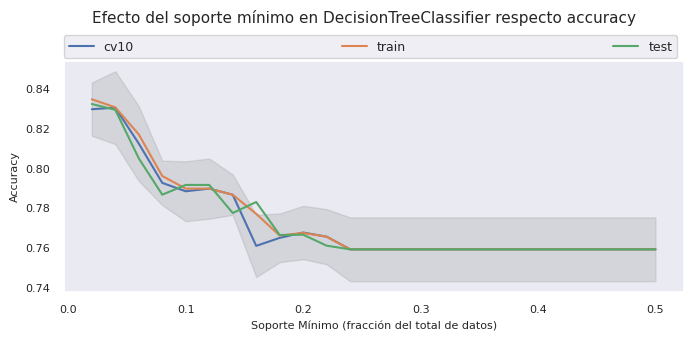

In [ ]:
cv_accuracies = np.array(cv_accuracies)
cv_std = np.array(cv_std)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(min_supp,cv_accuracies,label='cv10')
ax.plot(min_supp,train_accuracies,label='train')
ax.plot(min_supp,test_accuracies,label='test')
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0., fontsize=9)
ax.legend(bbox_to_anchor=(0.0, 1.01, 0.99, .102), loc='lower left', ncol=3, mode="expand", borderaxespad=0.,fontsize=9)
plt.fill_between(min_supp, cv_accuracies-1*cv_std, cv_accuracies+1*cv_std,color='gray', alpha=0.2)

ax.set_xlabel("Soporte Mínimo (fracción del total de datos)")
ax.set_ylabel("Accuracy")
fig.suptitle('Efecto del soporte mínimo en DecisionTreeClassifier respecto accuracy', y=1.05, size=11)
plt.show()

In [ ]:
cv_accuracies = np.array(cv_accuracies)
idx_max = np.argmax(cv_accuracies)

result_supp = {
    'parameter': min_supp[idx_max],
    'cv_accuracy': cv_accuracies[idx_max],
    'test_accuracy': test_accuracies[idx_max],
    'train accuracy': train_accuracies[idx_max]
}

In [ ]:
result_supp

{'parameter': 0.04,
 'cv_accuracy': 0.8304890742654658,
 'test_accuracy': 0.8294180869031168,
 'train accuracy': 0.830677673257823}

In [ ]:
print('Resumen Resultados:\n')

print('Profundidad máxima, parameter=max_depth')
print(result_prof)
print('\nPoda, parameter=ccp_alpha')
print(result_poda)
print('\nSoporte minimo, parameter=min_samples_leaf')
print(result_supp)

Resumen Resultados:

Profundidad máxima, parameter=max_depth
{'parameter': 7, 'cv_accuracy': 0.8494932083271813, 'test_accuracy': 0.8535237217871948, 'train accuracy': 0.8675369552697255}

Poda, parameter=ccp_alpha
{'parameter': 0.000939569710892197, 'cv_accuracy': 0.8527550568433485, 'test_accuracy': 0.8498387839705205, 'train accuracy': 0.8654252255711269}

Soporte minimo, parameter=min_samples_leaf
{'parameter': 0.04, 'cv_accuracy': 0.8304890742654658, 'test_accuracy': 0.8294180869031168, 'train accuracy': 0.830677673257823}


# P10. Más Allá de lo Evidente.

Haga cosas originales para merecer una nota excelente. Por ejemplo:

*   Estudie el efecto de balancear los datos de entrenamiento sobre el desempeño del modelo (Hint: para medir correctamente los beneficios de aprender mejor clases minoritarias debe emplear métricas apropiadas).


In [ ]:
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
import random

svm = SVC()
tree = DecisionTreeClassifier()
classifier = ((svm, 'svm'), (tree, 'tree'))

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_encoded, y_train)

rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_encoded, y_train)

smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_train_encoded, y_train)

data = ((X_train_encoded, y_train, 'original'), (X_smote, y_smote, 'SMOTE'), (X_rus, y_rus, 'RUS'), (X_smoteenn, y_smoteenn, 'SMOTEENN'))


for (clf, name_clf) in classifier:
    for (X, y, name_data) in data:
        print(name_clf, name_data, ':', cross_val_score(clf, X, y, scoring='f1_macro').mean())

# print(X_smote.shape,y_smote.shape, X_rus.shape,y_rus.shape,)

svm original : 0.7662762403726597
svm SMOTE : 0.8469558523680206
svm RUS : 0.7883778437528964
svm SMOTEENN : 0.9533899549992162
tree original : 0.7436436686244701
tree SMOTE : 0.8483059790324351
tree RUS : 0.7527137908847583
tree SMOTEENN : 0.9617054839621438


*   Averigue si existe una forma de predecir probabilidades a partir de una SVM. Aplique este método para identificar algunos datos que este modelo predice con mucha incertidumbre y discuta las aplicaciones que podría tener esto.


In [ ]:
svm = SVC(probability=True)
svm.fit(X_train_encoded, y_train)

SVC(probability=True)

In [ ]:
svm.predict_proba(X_test_encoded)

array([[0.13925953, 0.86074047],
       [0.92305933, 0.07694067],
       [0.91296782, 0.08703218],
       ...,
       [0.17997558, 0.82002442],
       [0.93567175, 0.06432825],
       [0.8681081 , 0.1318919 ]])

In [ ]:
idx = []
for i, coord in enumerate(svm.predict_proba(X_test_encoded)):
    if max(abs(coord)) < 0.7:
        idx.append(i)
len(idx)

594

*   Averigue en qué consiste el método de Nystroem para aproximar kerneles no lineales, impleméntelo, y determina si funciona en la práctica.

In [ ]:
from sklearn.kernel_approximation import Nystroem
from sklearn.model_selection import cross_val_score
import time

data_train=data_train_large

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

X_train_encoded = data_train[continuous_features]
X_test_encoded = data_test[continuous_features]

continuous_scaler = MinMaxScaler()
continuous_scaler.fit(X_train_encoded)

X_train_encoded = pd.DataFrame(continuous_scaler.transform(X_train_encoded),columns=continuous_features)
X_test_encoded = pd.DataFrame(continuous_scaler.transform(X_test_encoded),columns=continuous_features)

categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']

categorical_encoder = OneHotEncoder(sparse=False)
cat_X_train_encoded = categorical_encoder.fit_transform(data_train[categorical_features])
cat_X_train_encoded = pd.DataFrame(cat_X_train_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.concat([X_train_encoded,cat_X_train_encoded],axis=1)
cat_X_test_encoded = categorical_encoder.transform(data_test[categorical_features])
cat_X_test_encoded = pd.DataFrame(cat_X_test_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_test_encoded = pd.concat([X_test_encoded,cat_X_test_encoded],axis=1)


le_class = LabelEncoder()

class_column = 'salary'
y_train = le_class.fit_transform(data_train[class_column])
y_test = le_class.transform(data_test[class_column])


start = time.time()
svm = SVC(kernel='rbf')
svm.fit(X_train_encoded, y_train)
end = time.time()
print('SVC RBF:')
print(' Training time:', end-start)
print(' Train score:    ', svm.score(X_train_encoded, y_train))
print(' Test score:     ', svm.score(X_test_encoded, y_test))
print(' CV score:       ', cross_val_score(svm, X_train_encoded, y_train, scoring='accuracy').mean())

start = time.time()
svm_nys = LinearSVC()
nys = Nystroem(kernel='rbf', n_components=50)
X_nys = nys.fit_transform(X_train_encoded)
svm_nys.fit(X_nys, y_train)
end = time.time()
print('SVC Nys:')
print(' Training time:', end-start)
print(' Train score:    ', svm_nys.score(X_nys, y_train))
print(' Test score:     ', svm_nys.score(nys.transform(X_test_encoded), y_test))
print(' CV score:       ', cross_val_score(svm_nys, X_nys, y_train, scoring='accuracy').mean())


SVC RBF:
 Training time: 33.9778938293457
 Train score:     0.8451941072028408
 Test score:      0.8384768923691079
 CV score:        0.8354525572695068
SVC Nys:
 Training time: 0.5326030254364014
 Train score:     0.8394356734968089
 Test score:      0.8344848764010441
 CV score:        0.836988215606859


In [ ]:
svm_nys.score(X_nys, y_train)

0.8394356734968089

*   Aproveche la colección grande de entrenamiento para determinar qué modelo se beneficia más al aumentar gradualmente el número de datos de entrenamiento (Hint: probablemente es más productivo utilizar una escala logarítimica. Por ejemplo duplicar el número de datos hasta alcanzar el total).

N datos done: 1302
N datos done: 2604
N datos done: 5209
N datos done: 10419
N datos done: 20839


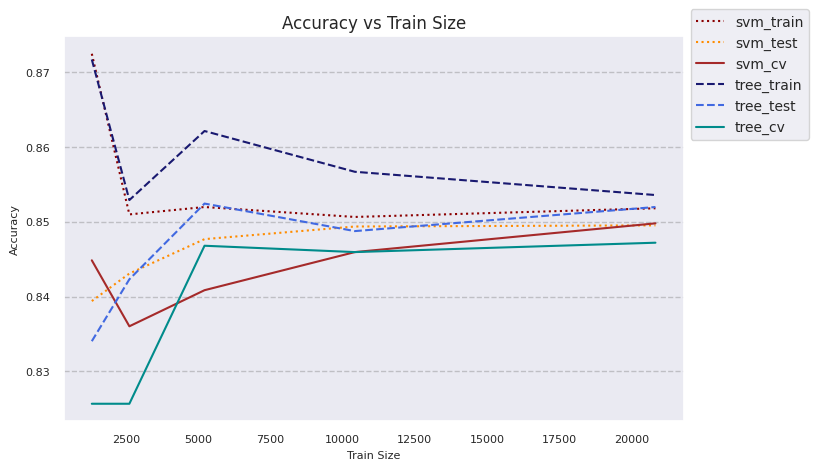

In [ ]:
data_train=data_train_large

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

continuous_features = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']

X_train_encoded = data_train[continuous_features]
X_test_encoded = data_test[continuous_features]

continuous_scaler = MinMaxScaler()
continuous_scaler.fit(X_train_encoded)

X_train_encoded = pd.DataFrame(continuous_scaler.transform(X_train_encoded),columns=continuous_features)
X_test_encoded = pd.DataFrame(continuous_scaler.transform(X_test_encoded),columns=continuous_features)

categorical_features = ['workclass', 'education', 'marital-status',  'occupation', 'relationship', 'race',  'sex',  'native-country']

categorical_encoder = OneHotEncoder(sparse=False)
cat_X_train_encoded = categorical_encoder.fit_transform(data_train[categorical_features])
cat_X_train_encoded = pd.DataFrame(cat_X_train_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.concat([X_train_encoded,cat_X_train_encoded],axis=1)
cat_X_test_encoded = categorical_encoder.transform(data_test[categorical_features])
cat_X_test_encoded = pd.DataFrame(cat_X_test_encoded,columns=categorical_encoder.get_feature_names_out(categorical_features))
X_test_encoded = pd.concat([X_test_encoded,cat_X_test_encoded],axis=1)


le_class = LabelEncoder()

class_column = 'salary'
y_train = le_class.fit_transform(data_train[class_column])
y_test = le_class.transform(data_test[class_column])

X=[]
y=[]
lens = []
lens.append(len(X_train_encoded))
X.append(X_train_encoded)
y.append(y_train)
for i in range(5):
  X_tr = X[i]
  y_tr=y[i]
  X_train_2, X_train_3,y_train_2,y_train_3= train_test_split(X_tr,y_tr,test_size = 0.5, random_state=42)
  X.append(X_train_2)
  y.append(y_train_2)

  lens.append(len(X_train_2))

tree_train_score = []
tree_test_score =[]
tree_cv_score = []
svm_train_score = []
svm_test_score = []
svm_cv_score = []

svm = LinearSVC(random_state=42)
tree = DecisionTreeClassifier(max_depth=7, criterion='entropy', random_state=42)
for i in range(4,-1,-1):
    svm.fit(X[i],y[i])
    tree.fit(X[i],y[i])
    svm_train_score.append(svm.score(X[i],y[i]))
    svm_test_score.append(svm.score(X_test_encoded,y_test))
    tree_train_score.append(tree.score(X[i],y[i]))
    tree_test_score.append((tree.score(X_test_encoded,y_test)))
    cv_svm = cross_val_score(svm, X[i], y[i], cv=3).mean()
    cv_tree = cross_val_score(tree, X[i], y[i], cv=3).mean()
    svm_cv_score.append(cv_svm)
    tree_cv_score.append(cv_tree)
    print('N datos done:', lens[i])


fig, ax = plt.subplots(figsize=(8,5))
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), svm_train_score, label='svm_train', color='darkred', linestyle='dotted')
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), svm_test_score, label='svm_test', color='darkorange', linestyle='dotted')
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), svm_cv_score, label='svm_cv', color='brown')
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), tree_train_score, label='tree_train', color='midnightblue', linestyle='dashed')
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), tree_test_score, label='tree_test', color='royalblue', linestyle='dashed')
plt.plot(np.floor(np.logspace(-4, 0, num=5, endpoint=True, base=2)*20839), tree_cv_score, label='tree_cv', color='darkcyan')

ax.set_xlabel('Train Size')
ax.set_ylabel('Accuracy')
ax.set_title("Accuracy vs Train Size")
ax.yaxis.grid(color='gray', linestyle='dashed', alpha=0.4)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.9),fontsize=10)
plt.show()

# Referencias
- Documentación Sklearn, Pandas, Imbalanced Learn, Matplotlib.
- Videos pandémicos